# Лабораторная работа №4

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_validate
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import (BaggingClassifier, BaggingRegressor,
                              RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              AdaBoostClassifier, AdaBoostRegressor,
                              StackingClassifier, StackingRegressor)
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             mean_squared_error, mean_absolute_error, r2_score, confusion_matrix, RocCurveDisplay, classification_report)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor


import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier, CatBoostRegressor
# from py_boost import GradientBoosting

import optuna

RNG_SEED = 42
np.random.seed(RNG_SEED)

### Загрузка датасетов

In [2]:
df_wine = pd.read_csv('../data/final_data_wine.csv', index_col=0)
df_wine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,0.164343,2.283475,-2.279442,-0.749952,1.238001,-1.133138,-1.467934,1.092436,1.808131,0.263930,-0.938658,5,1
1,0.477600,3.405904,-2.279442,-0.601255,2.344580,-0.322206,-0.876417,0.751612,-0.125112,1.160428,-0.603680,5,1
2,0.477600,2.657618,-1.988649,-0.664982,2.042786,-0.901443,-1.109439,0.819769,0.249064,0.936303,-0.603680,5,1
3,3.140279,-0.335528,1.791656,-0.749952,1.187702,-0.785596,-1.001890,1.160613,-0.374562,0.413346,-0.603680,6,1
4,0.164343,2.283475,-2.279442,-0.749952,1.238001,-1.133138,-1.467934,1.092436,1.808131,0.263930,-0.938658,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,-0.775426,-0.772028,-0.171195,-0.813679,-0.623063,-0.380130,-0.428298,-1.177475,0.311427,-0.184319,0.568742,6,0
4894,-0.462170,-0.086099,0.337693,0.545837,-0.220671,1.531351,0.933984,0.104033,-0.436925,-0.483152,-0.771169,5,0
4895,-0.540484,-0.584956,-0.898176,-0.898649,-0.522465,-0.032588,-0.087728,-0.700317,-1.434728,-0.483152,-0.938658,6,0
4896,-1.323625,-0.273170,-0.098496,-0.919892,-1.478147,-0.611825,-0.105652,-2.012500,0.747965,-1.080818,1.908654,7,0


In [3]:
df_wine.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5974 entries, 0 to 4897
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         5974 non-null   float64
 1   volatile acidity      5974 non-null   float64
 2   citric acid           5974 non-null   float64
 3   residual sugar        5974 non-null   float64
 4   chlorides             5974 non-null   float64
 5   free sulfur dioxide   5974 non-null   float64
 6   total sulfur dioxide  5974 non-null   float64
 7   density               5974 non-null   float64
 8   pH                    5974 non-null   float64
 9   sulphates             5974 non-null   float64
 10  alcohol               5974 non-null   float64
 11  quality               5974 non-null   int64  
 12  type                  5974 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 653.4 KB


In [4]:
df_diamonds = pd.read_csv("../data/final_data_diamonds.csv", index_col=0)
df_diamonds

,carat,cut,color,clarity,depth,table,price,x,y,z
0,-1.199341,4,5,1,-0.176252,-1.096824,326,-1.587838,-1.573374,-1.593630
1,-1.241582,3,5,2,-1.381332,1.591635,326,-1.641325,-1.699003,-1.766179
2,-1.199341,1,5,4,-3.437054,3.383941,327,-1.498691,-1.492612,-1.766179
3,-1.072620,3,1,3,0.461732,0.247406,334,-1.364972,-1.349036,-1.306050
4,-1.030379,1,0,1,1.099714,0.247406,335,-1.240166,-1.241354,-1.133502
...,...,...,...,...,...,...,...,...,...,...
53935,-0.164447,4,6,2,-0.672462,-0.200671,2757,0.016798,0.023908,-0.055076
53936,-0.164447,1,6,2,0.957939,-1.096824,2757,-0.036690,0.014935,0.103093
53937,-0.206688,2,6,2,0.745278,1.143559,2757,-0.063434,-0.047880,0.031198
53938,0.131237,3,2,1,-0.530687,0.247406,2757,0.373383,0.346954,0.290021


In [5]:
df_diamonds.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  int64  
 2   color    53940 non-null  int64  
 3   clarity  53940 non-null  int64  
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(4)
memory usage: 4.5 MB


### Выделеение целевого признака и предиктора, разделение на выборки

In [6]:
X_wine = df_wine.drop(columns=['type'])
y_wine = df_wine['type']
print(X_wine.shape, y_wine.shape)
print(y_wine.value_counts())

(5974, 12) (5974,)
type
0    4575
1    1399
Name: count, dtype: int64


In [7]:
X_diamonds = df_diamonds.drop(columns=["price"])
y_diamonds = df_diamonds['price']
print(X_diamonds.shape, y_diamonds.shape)
print(y_diamonds.value_counts())

(53940, 9) (53940,)
price
605      132
802      127
625      126
828      125
776      124
        ... 
8816       1
14704      1
14699      1
14698      1
9793       1
Name: count, Length: 11602, dtype: int64


### Разделение данных

In [8]:
X_temp_wine, X_test_wine, y_temp_wine, y_test_wine = train_test_split(X_wine, y_wine, test_size=0.2, stratify=y_wine, random_state=RNG_SEED)
X_train_wine, X_val_wine, y_train_wine, y_val_wine = train_test_split(X_temp_wine, y_temp_wine, test_size=0.25, stratify=y_temp_wine, random_state=RNG_SEED)

print(X_train_wine.shape, X_val_wine.shape, X_test_wine.shape)
print(y_train_wine.shape, X_val_wine.shape, y_test_wine.shape)


(3584, 12) (1195, 12) (1195, 12)
(3584,) (1195, 12) (1195,)


In [9]:
X_temp_diamonds, X_test_diamonds, y_temp_diamonds, y_test_diamonds = train_test_split(X_diamonds, y_diamonds, test_size=0.2, random_state=RNG_SEED)
X_train_diamonds, X_val_diamonds, y_train_diamonds, y_val_diamonds = train_test_split(X_temp_diamonds, y_temp_diamonds, test_size=0.25, random_state=RNG_SEED)

print(X_train_diamonds.shape, X_val_diamonds.shape, X_test_diamonds.shape)
print(y_train_diamonds.shape, X_val_diamonds.shape, y_test_diamonds.shape)

(32364, 9) (10788, 9) (10788, 9)
(32364,) (10788, 9) (10788,)


### Балансировка

In [10]:
y_train_wine.value_counts()

type
0    2745
1     839
Name: count, dtype: int64

In [11]:
oversample = SMOTE()

X_train_bal_wine, y_train_bal_wine = oversample.fit_resample(X_train_wine, y_train_wine)
y_train_bal_wine.value_counts()

type
0    2745
1    2745
Name: count, dtype: int64

### Вспомогательные функции

In [12]:
def calculate_metrics_cls(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted'),
        'Recall': recall_score(y_true, y_pred, average='weighted'),
        'F1': f1_score(y_true, y_pred, average='weighted')
    }

def calculate_metrics_reg(y_true, y_pred):
    return {
        'R2': r2_score(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mean_squared_error(y_true, y_pred),
    }

def fmt(val, metric_name):
    if 'R2' in metric_name or 'F1' in metric_name:
        prec = 2
    else:
        prec = 4
    return f"{val:.{prec}f}"


def plot_and_extract_rules(model, X_train, feature_names):
    plt.figure(figsize=(20, 10))
    plot_tree(model, feature_names=feature_names, class_names=['White', 'Red'], 
              filled=True, max_depth=3, fontsize=10)
    plt.title("Decision Tree Visualization")
    plt.show()
    
    from sklearn.tree import _tree
    
    tree = model.tree_
    rules = []
    
    def extract_rules(node, conditions):
        if tree.feature[node] != _tree.TREE_UNDEFINED:
            feature = feature_names[tree.feature[node]]
            threshold = tree.threshold[node]
            
            extract_rules(tree.children_left[node], 
                         conditions + [f"{feature} <= {threshold:.2f}"])
            extract_rules(tree.children_right[node], 
                         conditions + [f"{feature} > {threshold:.2f}"])
        else:
            class_name = 'Red' if tree.value[node][0][1] > tree.value[node][0][0] else 'White'
            rules.append(f"IF {' AND '.join(conditions)} THEN {class_name}")
    
    extract_rules(0, [])
    
    for rule in rules:
        print(f"  {rule}")

In [ ]:
base_cls_models = [
    ('rf', RandomForestClassifier(random_state=RNG_SEED)),
    ('xgb', xgb.XGBClassifier(random_state=RNG_SEED, eval_metric='logloss')),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
]

base_reg_models = [
    ('rf', RandomForestRegressor(random_state=RNG_SEED)),
    ('xgb', xgb.XGBRegressor(random_state=RNG_SEED)),
    ('knn', KNeighborsRegressor(n_neighbors=5)),
]

cls_models = {
    'DecisionTree': DecisionTreeClassifier(random_state=RNG_SEED),
    'Bagging': BaggingClassifier(random_state=RNG_SEED),
    'RandomForest': RandomForestClassifier(random_state=RNG_SEED),
    'GradientBoosting': GradientBoostingClassifier(random_state=RNG_SEED),
    'AdaBoost': AdaBoostClassifier(random_state=RNG_SEED),
    'XGBoost': xgb.XGBClassifier(random_state=RNG_SEED, eval_metric='logloss'),
    'LightGBM': lgb.LGBMClassifier(random_state=RNG_SEED, verbose=-1),
    'CatBoost': CatBoostClassifier(random_state=RNG_SEED, verbose=0),
    'Stacking': StackingClassifier(
        estimators=base_cls_models,
        final_estimator=LogisticRegression(max_iter=1000),
        cv=5
    )
}

reg_models = {
    'DecisionTree': DecisionTreeRegressor(random_state=RNG_SEED),
    'Bagging': BaggingRegressor(random_state=RNG_SEED),
    'RandomForest': RandomForestRegressor(random_state=RNG_SEED),
    'GradientBoosting': GradientBoostingRegressor(random_state=RNG_SEED),
    'AdaBoost': AdaBoostRegressor(random_state=RNG_SEED),
    'XGBoost': xgb.XGBRegressor(random_state=RNG_SEED),
    'LightGBM': lgb.LGBMRegressor(random_state=RNG_SEED, verbose=-1),
    'CatBoost': CatBoostRegressor(random_state=RNG_SEED, verbose=0),
    'Stacking': StackingRegressor(
        estimators=base_reg_models,
        final_estimator=Ridge(),
        cv=5
    )
}

cv_wine = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG_SEED)
cv_diamonds = KFold(n_splits=5, shuffle=True, random_state=RNG_SEED)

cls_results_wine = []
reg_results_diamonds = []

In [14]:
def train_evaluate_loop(models_dict, X_train, y_train, X_val, y_val, X_test, y_test, cv, task_type, metrics_func, res_list):
    if task_type == 'Classification':
        scorers = {
            'Accuracy': 'accuracy',
            'Precision': 'precision_weighted',
            'Recall': 'recall_weighted',
            'F1': 'f1_weighted'
        }
    else:
        scorers = {
            'R2': 'r2',
            'RMSE': 'neg_root_mean_squared_error',
            'MAE': 'neg_mean_absolute_error',
            'MSE': 'neg_mean_squared_error'
        }

    for name, model in models_dict.items():
        print(f"\n{task_type}: {name}")

        cv_res = cross_validate(model, X_train, y_train, cv=cv, scoring=scorers, n_jobs=-1)
        
        model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        
        metrics_train = metrics_func(y_train, y_pred_train)
        metrics_test = metrics_func(y_test, y_pred_test)
        
        row = {'Algorithm': name}
        for k in metrics_train.keys():
            row[('Train Data', k)] = fmt(metrics_train[k], k)
            row[('Test Data', k)] = fmt(metrics_test[k], k)
            
        for metric_name, scorer_name in scorers.items():
            scores = cv_res[f'test_{metric_name}']
            mean_v, std_v = abs(np.mean(scores)), abs(np.std(scores))
            
            if 'R2' in metric_name or 'F1' in metric_name:
                row[('K-Fold CV', f'{metric_name} (mean±std)')] = f"{mean_v:.2f} ± {std_v:.2f}"
            else:
                row[('K-Fold CV', f'{metric_name} (mean±std)')] = f"{mean_v:.4f} ± {std_v:.4f}"
            
        res_list.append(row)

        if task_type == 'Classification':
            print("    Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test))
            RocCurveDisplay.from_estimator(model, X_test, y_test)
            plt.title(f'ROC Curve - {name}')
            plt.show()
        
        print(f"    Train Metrics: { {k: fmt(metrics_train[k], k) for k in metrics_train} }")
        print(f"    Test Metrics: { {k: fmt(metrics_test[k], k) for k in metrics_test} }")
        
        if name == 'DecisionTree' and task_type == 'Classification':
            plot_and_extract_rules(model, X_train, X_train.columns)


Classification: DecisionTree
    Confusion Matrix:
 [[906   9]
 [  6 274]]


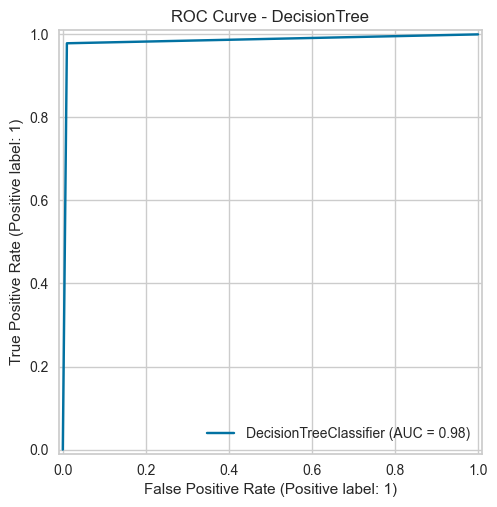

    Train Metrics: {'Accuracy': '1.0000', 'Precision': '1.0000', 'Recall': '1.0000', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9874', 'Precision': '0.9875', 'Recall': '0.9874', 'F1': '0.99'}


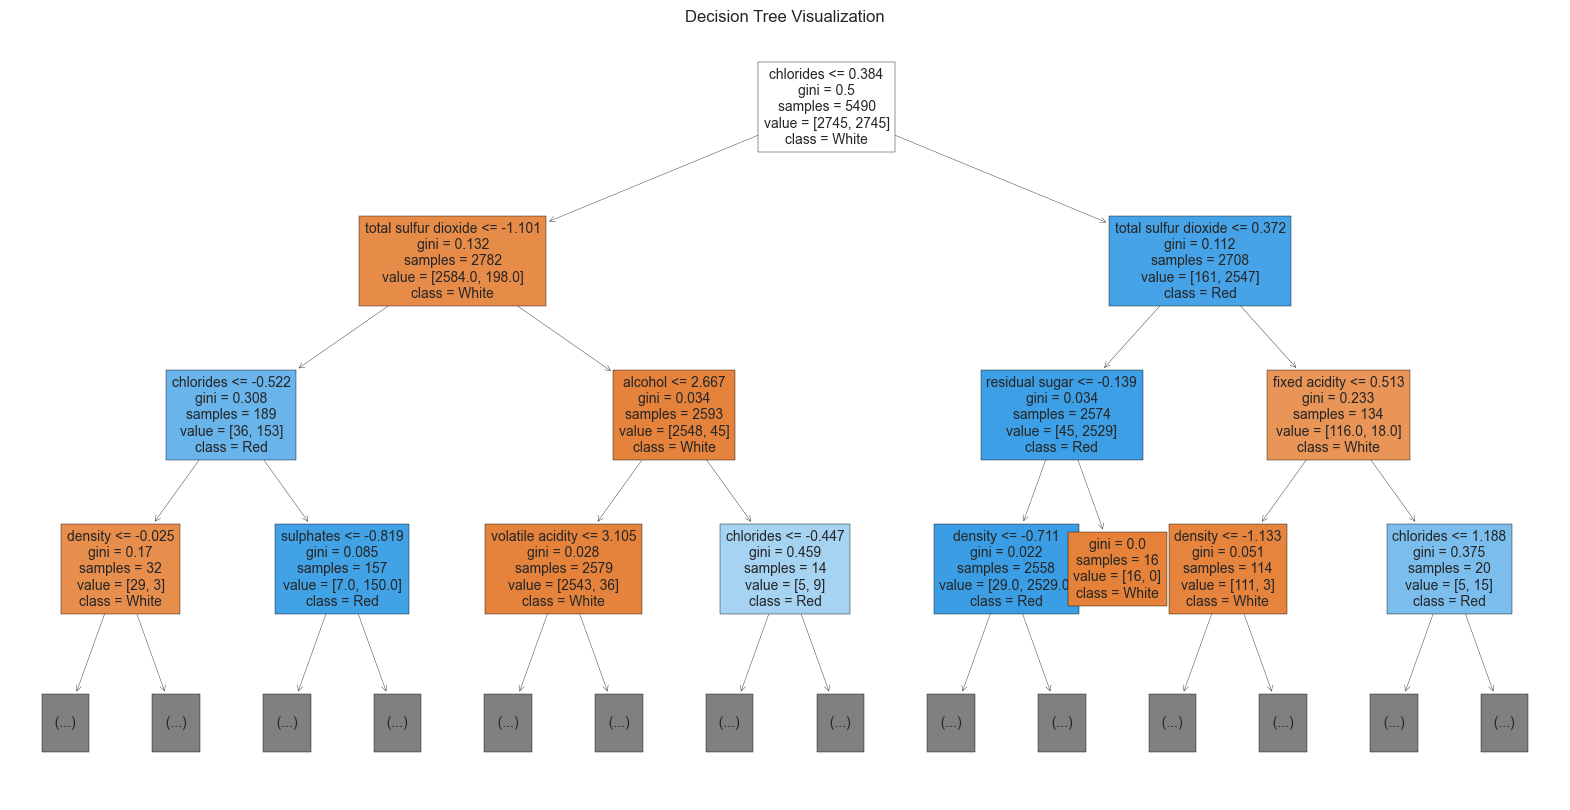

  IF chlorides <= 0.38 AND total sulfur dioxide <= -1.10 AND chlorides <= -0.52 AND density <= -0.03 THEN White
  IF chlorides <= 0.38 AND total sulfur dioxide <= -1.10 AND chlorides <= -0.52 AND density > -0.03 THEN Red
  IF chlorides <= 0.38 AND total sulfur dioxide <= -1.10 AND chlorides > -0.52 AND sulphates <= -0.82 AND chlorides <= 0.06 THEN White
  IF chlorides <= 0.38 AND total sulfur dioxide <= -1.10 AND chlorides > -0.52 AND sulphates <= -0.82 AND chlorides > 0.06 THEN Red
  IF chlorides <= 0.38 AND total sulfur dioxide <= -1.10 AND chlorides > -0.52 AND sulphates > -0.82 THEN Red
  IF chlorides <= 0.38 AND total sulfur dioxide > -1.10 AND alcohol <= 2.67 AND volatile acidity <= 3.11 AND chlorides <= -1.93 THEN Red
  IF chlorides <= 0.38 AND total sulfur dioxide > -1.10 AND alcohol <= 2.67 AND volatile acidity <= 3.11 AND chlorides > -1.93 AND pH <= 3.83 AND sulphates <= 2.22 AND total sulfur dioxide <= -0.92 AND chlorides <= -0.15 THEN White
  IF chlorides <= 0.38 AND total 

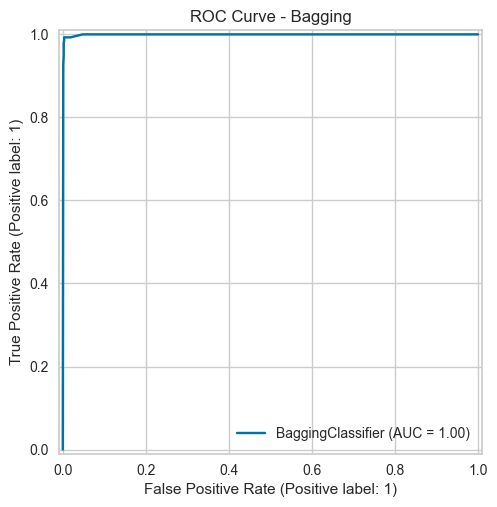

    Train Metrics: {'Accuracy': '0.9989', 'Precision': '0.9989', 'Recall': '0.9989', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9933', 'Precision': '0.9933', 'Recall': '0.9933', 'F1': '0.99'}

Classification: RandomForest
    Confusion Matrix:
 [[914   1]
 [  3 277]]


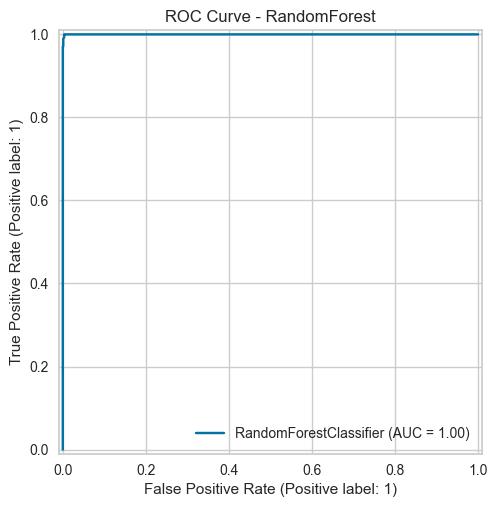

    Train Metrics: {'Accuracy': '1.0000', 'Precision': '1.0000', 'Recall': '1.0000', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9967', 'Precision': '0.9967', 'Recall': '0.9967', 'F1': '1.00'}

Classification: GradientBoosting
    Confusion Matrix:
 [[911   4]
 [  4 276]]


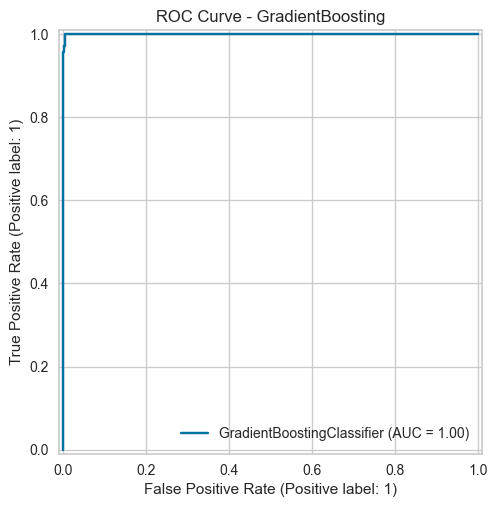

    Train Metrics: {'Accuracy': '0.9995', 'Precision': '0.9995', 'Recall': '0.9995', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9933', 'Precision': '0.9933', 'Recall': '0.9933', 'F1': '0.99'}

Classification: AdaBoost
    Confusion Matrix:
 [[909   6]
 [  2 278]]


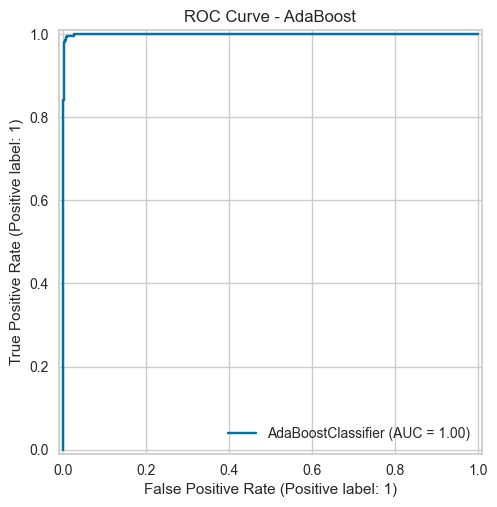

    Train Metrics: {'Accuracy': '0.9973', 'Precision': '0.9973', 'Recall': '0.9973', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9933', 'Precision': '0.9934', 'Recall': '0.9933', 'F1': '0.99'}

Classification: XGBoost
    Confusion Matrix:
 [[912   3]
 [  4 276]]


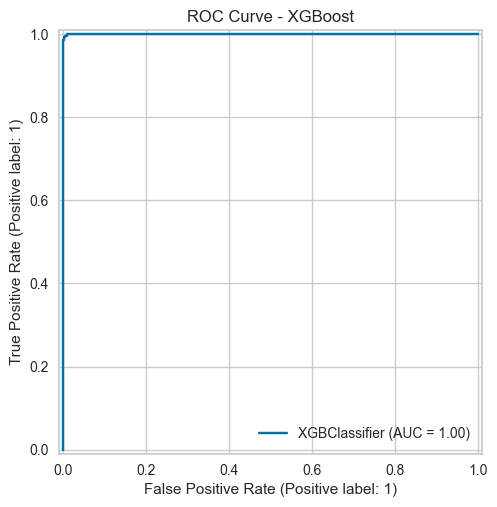

    Train Metrics: {'Accuracy': '1.0000', 'Precision': '1.0000', 'Recall': '1.0000', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9941', 'Precision': '0.9941', 'Recall': '0.9941', 'F1': '0.99'}

Classification: LightGBM


  File "c:\Users\danii\Desktop\git\master\mlbd\venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Users\danii\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\danii\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\danii\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 1456, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


    Confusion Matrix:
 [[914   1]
 [  3 277]]


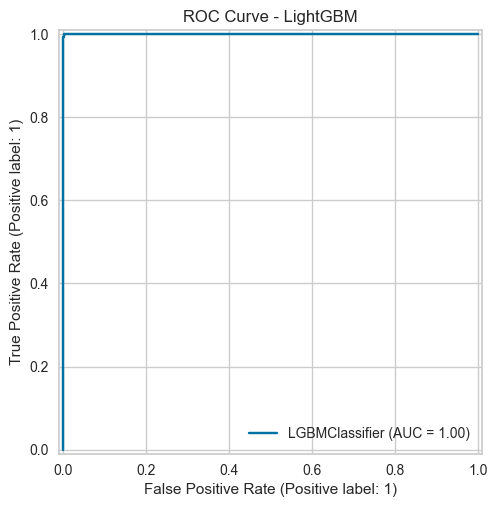

    Train Metrics: {'Accuracy': '1.0000', 'Precision': '1.0000', 'Recall': '1.0000', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9967', 'Precision': '0.9967', 'Recall': '0.9967', 'F1': '1.00'}

Classification: CatBoost
    Confusion Matrix:
 [[912   3]
 [  3 277]]


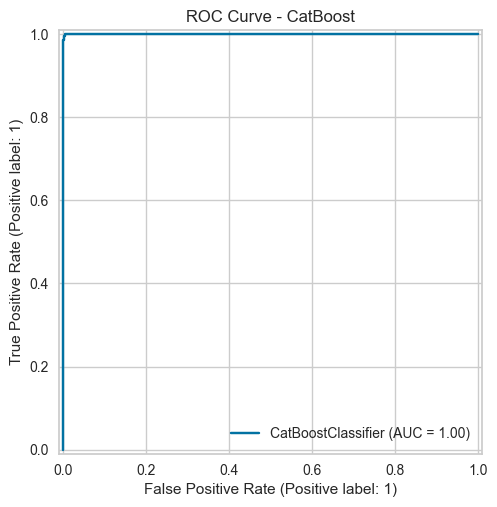

    Train Metrics: {'Accuracy': '1.0000', 'Precision': '1.0000', 'Recall': '1.0000', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9950', 'Precision': '0.9950', 'Recall': '0.9950', 'F1': '0.99'}

Classification: Stacking
    Confusion Matrix:
 [[914   1]
 [  5 275]]


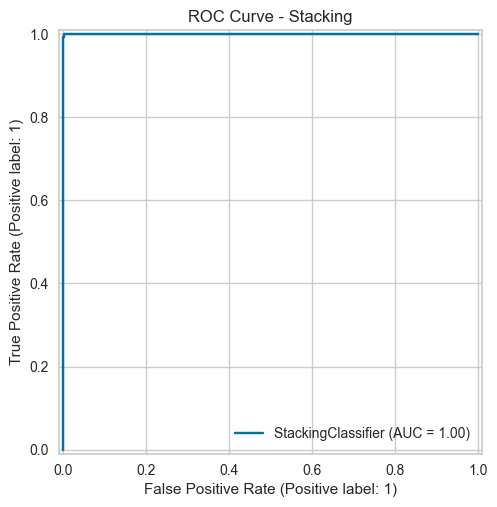

    Train Metrics: {'Accuracy': '1.0000', 'Precision': '1.0000', 'Recall': '1.0000', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9950', 'Precision': '0.9950', 'Recall': '0.9950', 'F1': '0.99'}


In [15]:
train_evaluate_loop(cls_models, X_train_bal_wine, y_train_bal_wine, X_val_wine, y_val_wine, X_test_wine, y_test_wine, cv_wine, 'Classification', calculate_metrics_cls, cls_results_wine)

In [16]:
train_evaluate_loop(reg_models, X_train_diamonds, y_train_diamonds, X_val_diamonds, y_val_diamonds, X_test_diamonds, y_test_diamonds, cv_diamonds, 'Regression', calculate_metrics_reg, reg_results_diamonds)


Regression: DecisionTree
    Train Metrics: {'R2': '1.00', 'RMSE': '6.8985', 'MAE': '0.3618', 'MSE': '47.5890'}
    Test Metrics: {'R2': '0.96', 'RMSE': '757.7050', 'MAE': '369.5366', 'MSE': '574116.9167'}

Regression: Bagging
    Train Metrics: {'R2': '1.00', 'RMSE': '240.6186', 'MAE': '113.8833', 'MSE': '57897.3175'}
    Test Metrics: {'R2': '0.98', 'RMSE': '574.8705', 'MAE': '287.7034', 'MSE': '330476.1430'}

Regression: RandomForest
    Train Metrics: {'R2': '1.00', 'RMSE': '204.1773', 'MAE': '101.4165', 'MSE': '41688.3727'}
    Test Metrics: {'R2': '0.98', 'RMSE': '551.1806', 'MAE': '273.1247', 'MSE': '303800.0374'}

Regression: GradientBoosting
    Train Metrics: {'R2': '0.98', 'RMSE': '593.8963', 'MAE': '335.2126', 'MSE': '352712.8376'}
    Test Metrics: {'R2': '0.98', 'RMSE': '605.5833', 'MAE': '337.9039', 'MSE': '366731.1416'}

Regression: AdaBoost
    Train Metrics: {'R2': '0.92', 'RMSE': '1116.2265', 'MAE': '845.5645', 'MSE': '1245961.6752'}
    Test Metrics: {'R2': '0.92',

In [17]:
reg_results_diamonds

[{'Algorithm': 'DecisionTree',
  ('Train Data', 'R2'): '1.00',
  ('Test Data', 'R2'): '0.96',
  ('Train Data', 'RMSE'): '6.8985',
  ('Test Data', 'RMSE'): '757.7050',
  ('Train Data', 'MAE'): '0.3618',
  ('Test Data', 'MAE'): '369.5366',
  ('Train Data', 'MSE'): '47.5890',
  ('Test Data', 'MSE'): '574116.9167',
  ('K-Fold CV', 'R2 (mean±std)'): '0.96 ± 0.00',
  ('K-Fold CV', 'RMSE (mean±std)'): '761.9796 ± 32.2573',
  ('K-Fold CV', 'MAE (mean±std)'): '380.3731 ± 12.1879',
  ('K-Fold CV', 'MSE (mean±std)'): '581653.4721 ± 47960.9530'},
 {'Algorithm': 'Bagging',
  ('Train Data', 'R2'): '1.00',
  ('Test Data', 'R2'): '0.98',
  ('Train Data', 'RMSE'): '240.6186',
  ('Test Data', 'RMSE'): '574.8705',
  ('Train Data', 'MAE'): '113.8833',
  ('Test Data', 'MAE'): '287.7034',
  ('Train Data', 'MSE'): '57897.3175',
  ('Test Data', 'MSE'): '330476.1430',
  ('K-Fold CV', 'R2 (mean±std)'): '0.98 ± 0.00',
  ('K-Fold CV', 'RMSE (mean±std)'): '586.7640 ± 15.3069',
  ('K-Fold CV', 'MAE (mean±std)'): '2

In [18]:
cls_results_wine

[{'Algorithm': 'DecisionTree',
  ('Train Data', 'Accuracy'): '1.0000',
  ('Test Data', 'Accuracy'): '0.9874',
  ('Train Data', 'Precision'): '1.0000',
  ('Test Data', 'Precision'): '0.9875',
  ('Train Data', 'Recall'): '1.0000',
  ('Test Data', 'Recall'): '0.9874',
  ('Train Data', 'F1'): '1.00',
  ('Test Data', 'F1'): '0.99',
  ('K-Fold CV', 'Accuracy (mean±std)'): '0.9893 ± 0.0034',
  ('K-Fold CV', 'Precision (mean±std)'): '0.9893 ± 0.0034',
  ('K-Fold CV', 'Recall (mean±std)'): '0.9893 ± 0.0034',
  ('K-Fold CV', 'F1 (mean±std)'): '0.99 ± 0.00'},
 {'Algorithm': 'Bagging',
  ('Train Data', 'Accuracy'): '0.9989',
  ('Test Data', 'Accuracy'): '0.9933',
  ('Train Data', 'Precision'): '0.9989',
  ('Test Data', 'Precision'): '0.9933',
  ('Train Data', 'Recall'): '0.9989',
  ('Test Data', 'Recall'): '0.9933',
  ('Train Data', 'F1'): '1.00',
  ('Test Data', 'F1'): '0.99',
  ('K-Fold CV', 'Accuracy (mean±std)'): '0.9933 ± 0.0015',
  ('K-Fold CV', 'Precision (mean±std)'): '0.9933 ± 0.0015',
  

In [19]:
CLS_HYPERPARAMS = {
    'DecisionTree': {'max_depth': [10, 20, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]},
    'Bagging': {'n_estimators': [50, 100], 'max_samples': [0.7, 1.0], 'bootstrap': [True, False]},
    'RandomForest': {'n_estimators': [100, 200], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5]},
    'GradientBoosting': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]},
    'AdaBoost': {'n_estimators': [50, 100], 'learning_rate': [0.5, 1.0]},
    'XGBoost': {'n_estimators': [100, 200], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]},
    'LightGBM': {'n_estimators': [100, 200], 'max_depth': [-1, 5], 'learning_rate': [0.05, 0.1], 'num_leaves': [31, 50]},
    'CatBoost': {'iterations': [100, 200], 'depth': [4, 6], 'learning_rate': [0.05, 0.1]}
}

REG_HYPERPARAMS = {
    'DecisionTree': {'max_depth': [10, 20, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]},
    'Bagging': {'n_estimators': [50, 100], 'max_samples': [0.7, 1.0], 'bootstrap': [True, False]},
    'RandomForest': {'n_estimators': [100, 200], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5]},
    'GradientBoosting': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]},
    'AdaBoost': {'n_estimators': [50, 100], 'learning_rate': [0.5, 1.0]},
    'XGBoost': {'n_estimators': [100, 200], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]},
    'LightGBM': {'n_estimators': [100, 200], 'max_depth': [-1, 5], 'learning_rate': [0.05, 0.1], 'num_leaves': [31, 50]},
    'CatBoost': {'iterations': [100, 200], 'depth': [4, 6], 'learning_rate': [0.05, 0.1]}
}

In [20]:
def run_optuna(model_name, model, X_train, y_train, cv, task_type='classification', n_trials=10):
    print(f"        Optuna ({n_trials} trials)...", end=' ')
    
    if task_type == 'classification':
        hyperparams = CLS_HYPERPARAMS.get(model_name, {})
        scoring = 'f1_weighted'
    else:
        hyperparams = REG_HYPERPARAMS.get(model_name, {})
        scoring = 'r2'
    
    def objective(trial):
        params = {}
        for param, values in hyperparams.items():
            if param in ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf', 
                         'iterations', 'depth', 'num_leaves']:
                if param == 'max_depth' and None in values:
                    params[param] = trial.suggest_categorical(param, values)
                else:
                    params[param] = trial.suggest_int(param, min(values), max(values))
            elif param in ['learning_rate']:
                params[param] = trial.suggest_float(param, min(values), max(values), log=True)
            else:
                params[param] = trial.suggest_categorical(param, values)
        
        model.set_params(**params)
        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
        return scores.mean()
    
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RNG_SEED))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    
    print(f"  best={study.best_value:.4f}")
    return study.best_value, study.best_params

def run_grid_search(model_name, model, X_train, y_train, cv, task_type='classification'):
    print(f"        Grid Search...", end=' ')
    
    if task_type == 'classification':
        hyperparams = CLS_HYPERPARAMS.get(model_name, {})
        scoring = 'f1_weighted'
    else:
        hyperparams = REG_HYPERPARAMS.get(model_name, {})
        scoring = 'r2'
    
    total = 1
    for v in hyperparams.values():
        total *= len(v)
    print(f"({total} комбинаций, берем 20)...", end=' ')
    
    search = RandomizedSearchCV(
        model, hyperparams, n_iter=min(20, total), cv=cv,
        scoring=scoring, n_jobs=-1, random_state=RNG_SEED
    )
    search.fit(X_train, y_train)
    
    print(f"  best={search.best_score_:.4f}")
    return search.best_score_, search.best_params_

def run_random_search(model_name, model, X_train, y_train, cv, task_type='classification', n_iter=10):
    print(f"        Random Search ({n_iter} итераций)...", end=' ')
    
    if task_type == 'classification':
        hyperparams = CLS_HYPERPARAMS.get(model_name, {})
        scoring = 'f1_weighted'
    else:
        hyperparams = REG_HYPERPARAMS.get(model_name, {})
        scoring = 'r2'
    
    search = RandomizedSearchCV(
        model, hyperparams, n_iter=n_iter, cv=cv,
        scoring=scoring, n_jobs=-1, random_state=RNG_SEED
    )
    search.fit(X_train, y_train)
    
    print(f"  best={search.best_score_:.4f}")
    return search.best_score_, search.best_params_

In [ ]:
def train_evaluate_loop_optimized(models_dict, X_train, y_train, X_val, y_val, X_test, y_test, cv, task_type, metrics_func, res_list):
    if task_type == 'Classification':
        scorers = {
            'Accuracy': 'accuracy',
            'Precision': 'precision_weighted',
            'Recall': 'recall_weighted',
            'F1': 'f1_weighted'
        }
    else:
        scorers = {
            'R2': 'r2',
            'RMSE': 'neg_root_mean_squared_error',
            'MAE': 'neg_mean_absolute_error',
            'MSE': 'neg_mean_squared_error'
        }

    strategies = [
        ('_optuna', 'Optuna', run_optuna),
        ('_random', 'Random', run_random_search),
        ('_grid', 'Grid', run_grid_search)
    ]

    for name, base_model in models_dict.items():
        
        for suffix, strategy_name, opt_func in strategies:
            current_model_name = f"{name}{suffix}"
            print(f"\n{task_type}: {current_model_name} [{strategy_name}]")

            model = clone(base_model)

            if opt_func:
                try:
                    best_score, best_params = opt_func(name, model, X_train, y_train, cv, task_type)
                    
                    model.set_params(**best_params)
                    print(f"    Applied best params for {current_model_name}")
                except Exception as e:
                    print(f"    Optimization failed for {current_model_name}: {e}")
            
            cv_res = cross_validate(model, X_train, y_train, cv=cv, scoring=scorers, n_jobs=-1)
            
            model.fit(X_train, y_train)
            y_pred_train = model.predict(X_train)
            y_pred_test = model.predict(X_test)
            
            metrics_train = metrics_func(y_train, y_pred_train)
            metrics_test = metrics_func(y_test, y_pred_test)
            
            row = {'Algorithm': current_model_name}
            for k in metrics_train.keys():
                row[('Train Data', k)] = fmt(metrics_train[k], k)
                row[('Test Data', k)] = fmt(metrics_test[k], k)
                
            for metric_name, scorer_name in scorers.items():
                scores = cv_res[f'test_{metric_name}']
                mean_v, std_v = abs(np.mean(scores)), abs(np.std(scores))
                
                if 'R2' in metric_name or 'F1' in metric_name:
                    row[('K-Fold CV', f'{metric_name} (mean±std)')] = f"{mean_v:.2f} ± {std_v:.2f}"
                else:
                    row[('K-Fold CV', f'{metric_name} (mean±std)')] = f"{mean_v:.4f} ± {std_v:.4f}"
                
            res_list.append(row)

            if task_type == 'Classification':
                print("    Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test))
                try:
                    RocCurveDisplay.from_estimator(model, X_test, y_test)
                    plt.title(f'ROC Curve - {current_model_name}')
                    plt.show()
                except:
                    pass
            
            print(f"    Train Metrics: { {k: fmt(metrics_train[k], k) for k in metrics_train} }")
            print(f"    Test Metrics: { {k: fmt(metrics_test[k], k) for k in metrics_test} }")
            
            if 'DecisionTree' in current_model_name and task_type == 'Classification':
                plot_and_extract_rules(model, X_train, X_train.columns)

[I 2026-05-04 01:27:32,300] A new study created in memory with name: no-name-b876bee5-bea5-4a42-8a82-ac5d764989ec



Classification: DecisionTree_optuna [Optuna]
        Optuna (10 trials)... 

[I 2026-05-04 01:27:32,395] Trial 0 finished with value: 0.9533697632058289 and parameters: {'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.9533697632058289.
[I 2026-05-04 01:27:32,475] Trial 1 finished with value: 0.9453551912568307 and parameters: {'max_depth': None, 'min_samples_split': 7, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.9533697632058289.
[I 2026-05-04 01:27:32,543] Trial 2 finished with value: 0.951183970856102 and parameters: {'max_depth': 20, 'min_samples_split': 3, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.9533697632058289.
[I 2026-05-04 01:27:32,623] Trial 3 finished with value: 0.951183970856102 and parameters: {'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.9533697632058289.
[I 2026-05-04 01:27:32,702] Trial 4 finished with value: 0.9519125683060109 and parameters: {'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 2}. Best is trial 0 

  best=0.9585
    Applied best params for DecisionTree_optuna
    Confusion Matrix:
 [[907   8]
 [  8 272]]


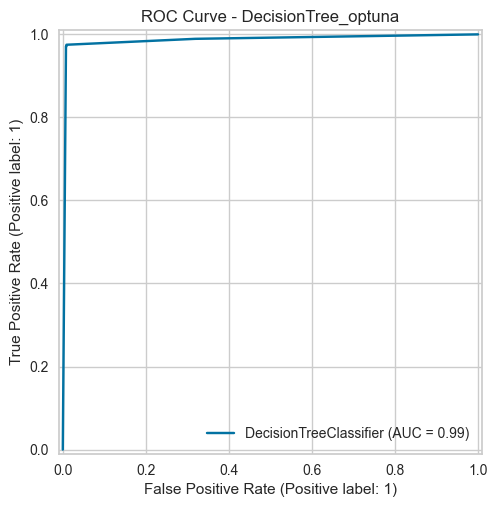

    Train Metrics: {'Accuracy': '0.9967', 'Precision': '0.9967', 'Recall': '0.9967', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9866', 'Precision': '0.9866', 'Recall': '0.9866', 'F1': '0.99'}


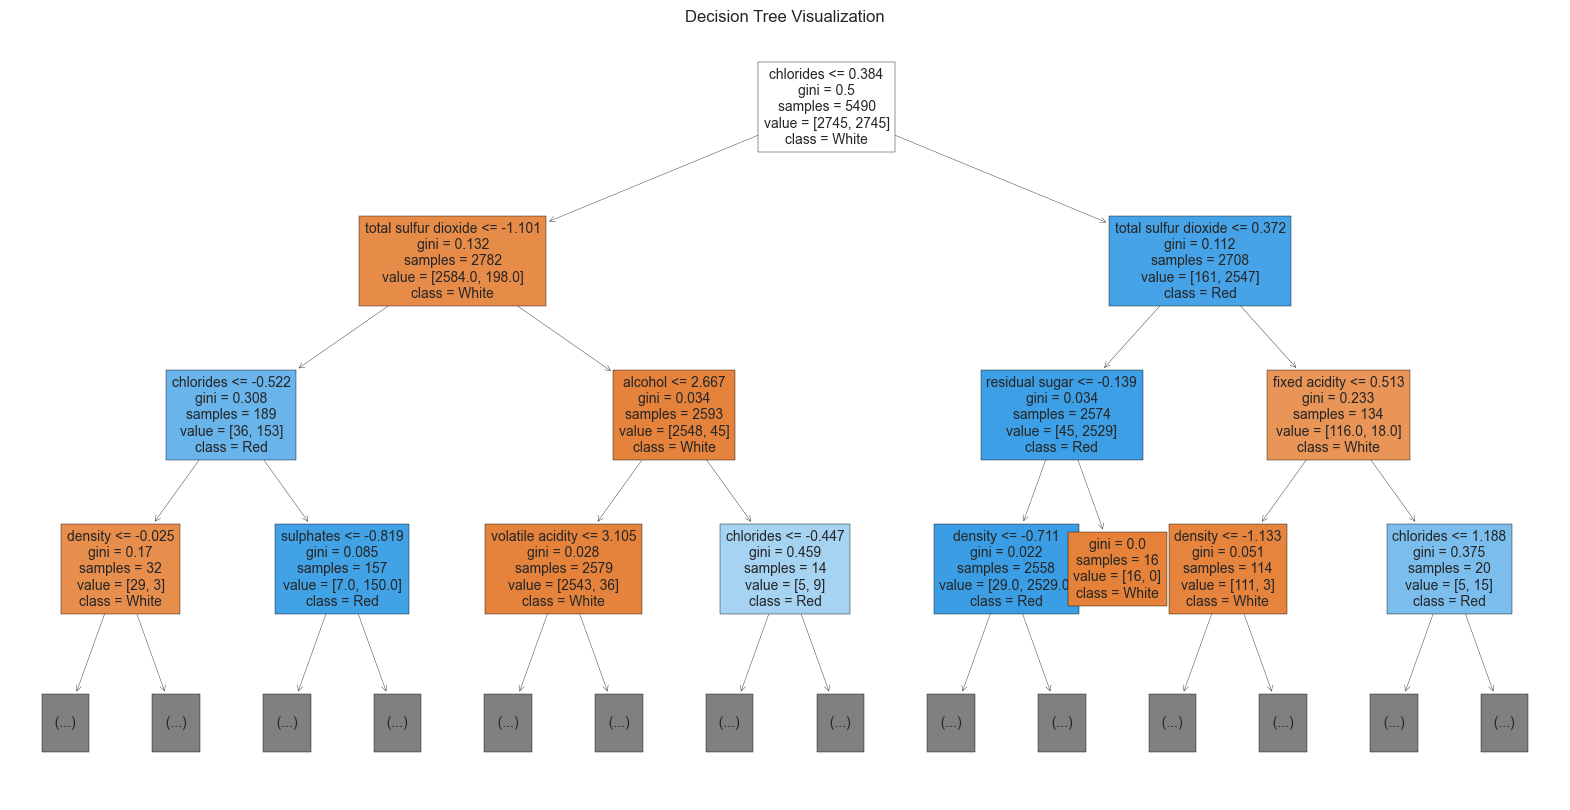

  IF chlorides <= 0.38 AND total sulfur dioxide <= -1.10 AND chlorides <= -0.52 AND density <= -0.03 THEN White
  IF chlorides <= 0.38 AND total sulfur dioxide <= -1.10 AND chlorides <= -0.52 AND density > -0.03 THEN Red
  IF chlorides <= 0.38 AND total sulfur dioxide <= -1.10 AND chlorides > -0.52 AND sulphates <= -0.82 AND chlorides <= 0.06 THEN White
  IF chlorides <= 0.38 AND total sulfur dioxide <= -1.10 AND chlorides > -0.52 AND sulphates <= -0.82 AND chlorides > 0.06 THEN Red
  IF chlorides <= 0.38 AND total sulfur dioxide <= -1.10 AND chlorides > -0.52 AND sulphates > -0.82 THEN Red
  IF chlorides <= 0.38 AND total sulfur dioxide > -1.10 AND alcohol <= 2.67 AND volatile acidity <= 3.11 AND chlorides <= -1.93 THEN Red
  IF chlorides <= 0.38 AND total sulfur dioxide > -1.10 AND alcohol <= 2.67 AND volatile acidity <= 3.11 AND chlorides > -1.93 AND pH <= 3.83 AND sulphates <= 2.22 AND total sulfur dioxide <= -0.92 AND chlorides <= -0.15 THEN White
  IF chlorides <= 0.38 AND total 

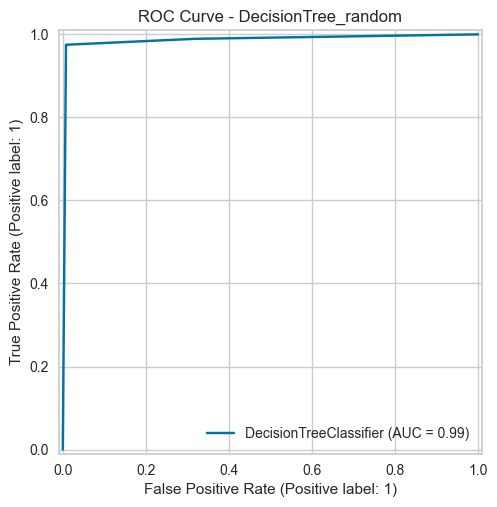

    Train Metrics: {'Accuracy': '0.9971', 'Precision': '0.9971', 'Recall': '0.9971', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9874', 'Precision': '0.9874', 'Recall': '0.9874', 'F1': '0.99'}


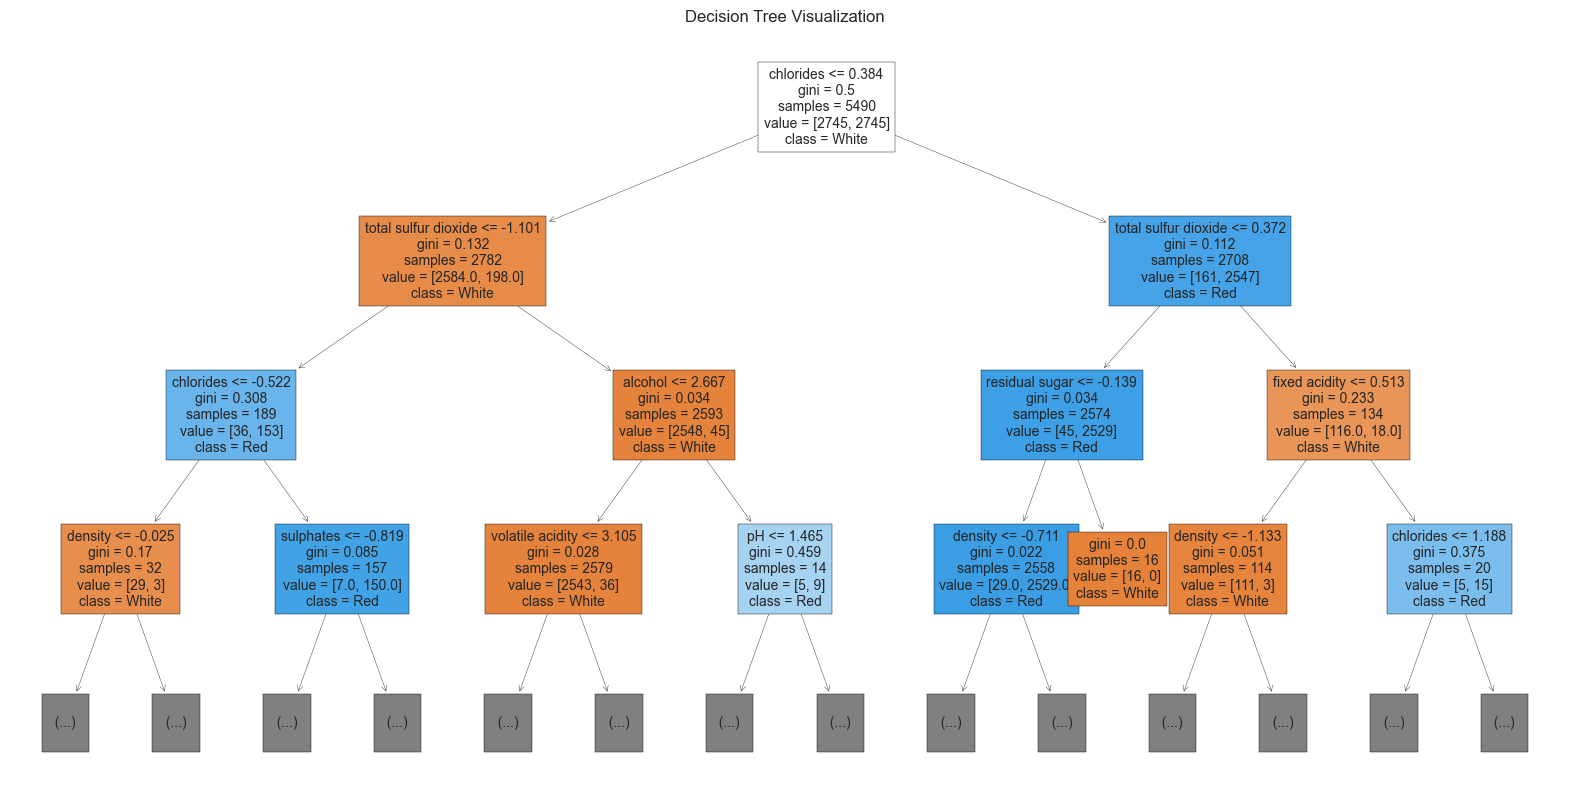

  IF chlorides <= 0.38 AND total sulfur dioxide <= -1.10 AND chlorides <= -0.52 AND density <= -0.03 THEN White
  IF chlorides <= 0.38 AND total sulfur dioxide <= -1.10 AND chlorides <= -0.52 AND density > -0.03 THEN Red
  IF chlorides <= 0.38 AND total sulfur dioxide <= -1.10 AND chlorides > -0.52 AND sulphates <= -0.82 AND chlorides <= 0.06 THEN White
  IF chlorides <= 0.38 AND total sulfur dioxide <= -1.10 AND chlorides > -0.52 AND sulphates <= -0.82 AND chlorides > 0.06 THEN Red
  IF chlorides <= 0.38 AND total sulfur dioxide <= -1.10 AND chlorides > -0.52 AND sulphates > -0.82 THEN Red
  IF chlorides <= 0.38 AND total sulfur dioxide > -1.10 AND alcohol <= 2.67 AND volatile acidity <= 3.11 AND chlorides <= -1.93 THEN Red
  IF chlorides <= 0.38 AND total sulfur dioxide > -1.10 AND alcohol <= 2.67 AND volatile acidity <= 3.11 AND chlorides > -1.93 AND pH <= 3.83 AND sulphates <= 2.22 AND total sulfur dioxide <= -0.92 AND chlorides <= -0.15 THEN White
  IF chlorides <= 0.38 AND total 

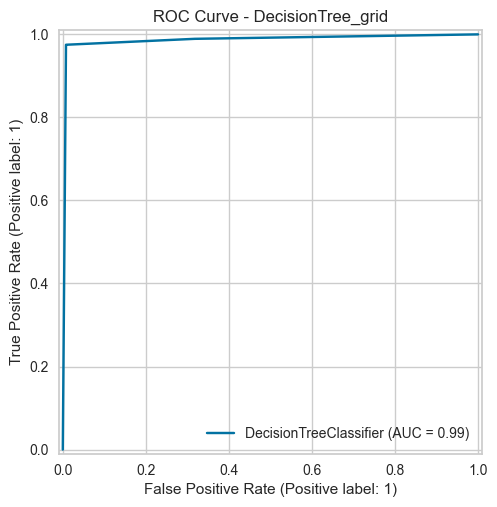

    Train Metrics: {'Accuracy': '0.9971', 'Precision': '0.9971', 'Recall': '0.9971', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9874', 'Precision': '0.9874', 'Recall': '0.9874', 'F1': '0.99'}


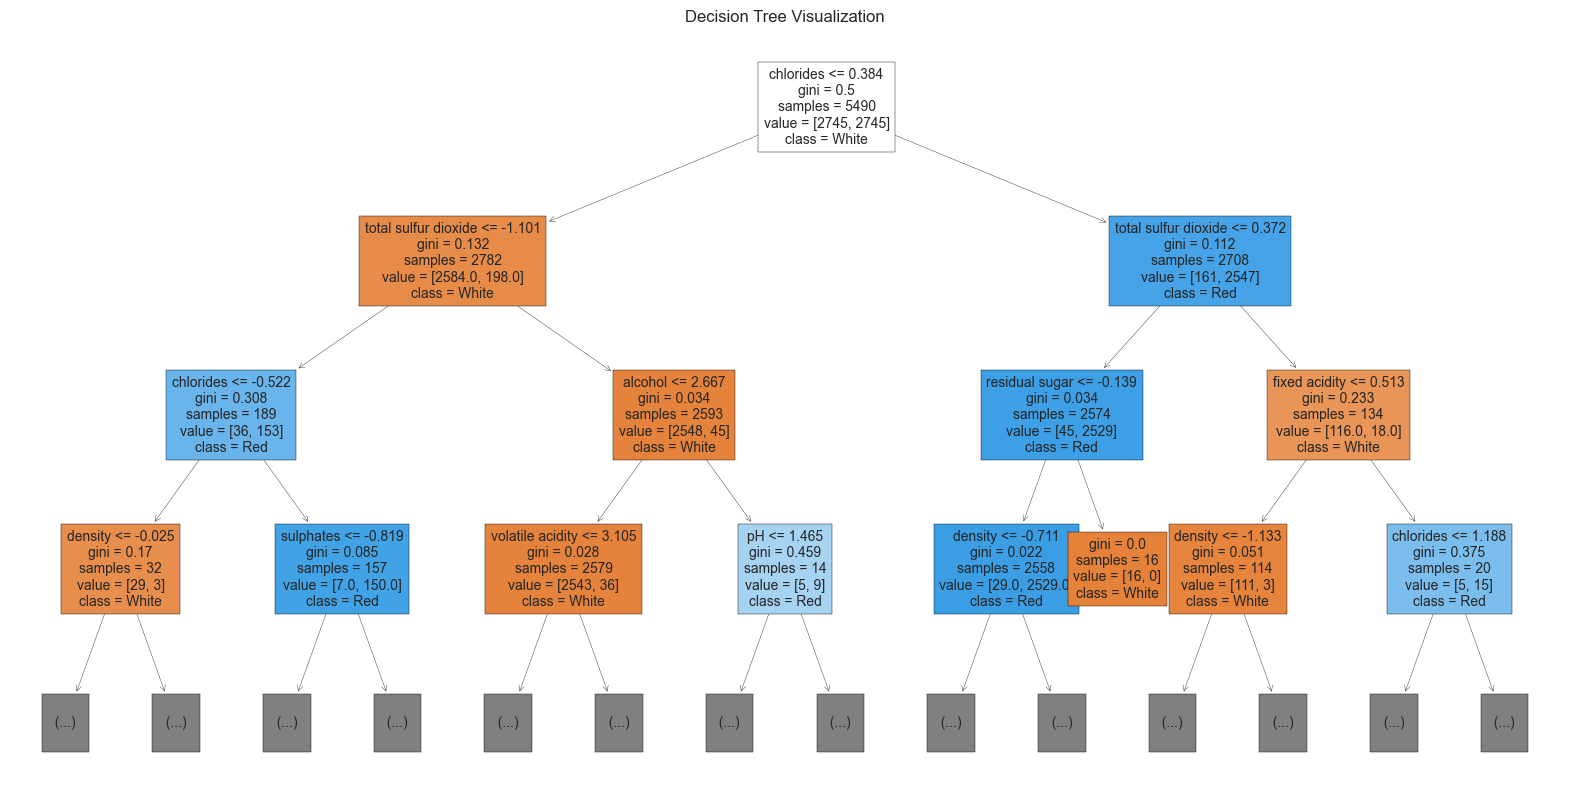

[I 2026-05-04 01:27:37,169] A new study created in memory with name: no-name-74e0a00e-3648-4976-9ca4-71ea63120eaf


  IF chlorides <= 0.38 AND total sulfur dioxide <= -1.10 AND chlorides <= -0.52 AND density <= -0.03 THEN White
  IF chlorides <= 0.38 AND total sulfur dioxide <= -1.10 AND chlorides <= -0.52 AND density > -0.03 THEN Red
  IF chlorides <= 0.38 AND total sulfur dioxide <= -1.10 AND chlorides > -0.52 AND sulphates <= -0.82 AND chlorides <= 0.06 THEN White
  IF chlorides <= 0.38 AND total sulfur dioxide <= -1.10 AND chlorides > -0.52 AND sulphates <= -0.82 AND chlorides > 0.06 THEN Red
  IF chlorides <= 0.38 AND total sulfur dioxide <= -1.10 AND chlorides > -0.52 AND sulphates > -0.82 THEN Red
  IF chlorides <= 0.38 AND total sulfur dioxide > -1.10 AND alcohol <= 2.67 AND volatile acidity <= 3.11 AND chlorides <= -1.93 THEN Red
  IF chlorides <= 0.38 AND total sulfur dioxide > -1.10 AND alcohol <= 2.67 AND volatile acidity <= 3.11 AND chlorides > -1.93 AND pH <= 3.83 AND sulphates <= 2.22 AND total sulfur dioxide <= -0.92 AND chlorides <= -0.15 THEN White
  IF chlorides <= 0.38 AND total 

[I 2026-05-04 01:27:38,393] Trial 0 finished with value: 0.9730418943533697 and parameters: {'n_estimators': 69, 'max_samples': 0.7, 'bootstrap': True}. Best is trial 0 with value: 0.9730418943533697.
[I 2026-05-04 01:27:40,987] Trial 1 finished with value: 0.9599271402550091 and parameters: {'n_estimators': 57, 'max_samples': 1.0, 'bootstrap': False}. Best is trial 0 with value: 0.9730418943533697.
[I 2026-05-04 01:27:41,947] Trial 2 finished with value: 0.9715846994535517 and parameters: {'n_estimators': 51, 'max_samples': 0.7, 'bootstrap': True}. Best is trial 0 with value: 0.9730418943533697.
[I 2026-05-04 01:27:43,343] Trial 3 finished with value: 0.9744990892531877 and parameters: {'n_estimators': 59, 'max_samples': 1.0, 'bootstrap': True}. Best is trial 3 with value: 0.9744990892531877.
[I 2026-05-04 01:27:47,104] Trial 4 finished with value: 0.9584699453551913 and parameters: {'n_estimators': 81, 'max_samples': 1.0, 'bootstrap': False}. Best is trial 3 with value: 0.97449908925

  best=0.9752
    Applied best params for Bagging_optuna
    Confusion Matrix:
 [[912   3]
 [  6 274]]


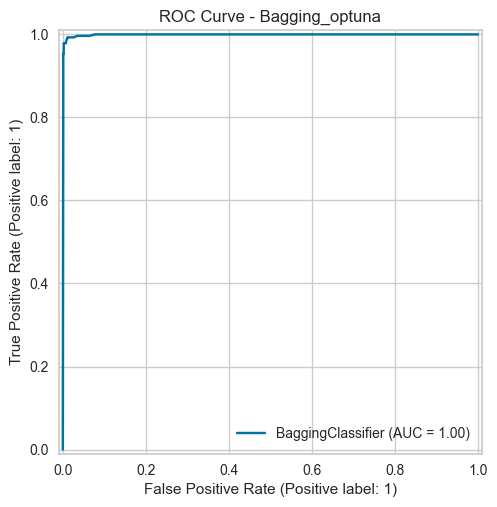

    Train Metrics: {'Accuracy': '1.0000', 'Precision': '1.0000', 'Recall': '1.0000', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9925', 'Precision': '0.9925', 'Recall': '0.9925', 'F1': '0.99'}

Classification: Bagging_random [Random]
        Random Search (10 итераций)...   best=0.9760
    Applied best params for Bagging_random
    Confusion Matrix:
 [[912   3]
 [  6 274]]


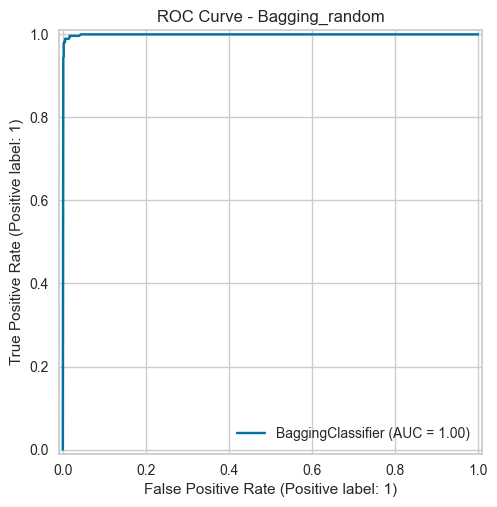

    Train Metrics: {'Accuracy': '1.0000', 'Precision': '1.0000', 'Recall': '1.0000', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9925', 'Precision': '0.9925', 'Recall': '0.9925', 'F1': '0.99'}

Classification: Bagging_grid [Grid]
        Grid Search... (8 комбинаций, берем 20)...   best=0.9760
    Applied best params for Bagging_grid
    Confusion Matrix:
 [[912   3]
 [  6 274]]


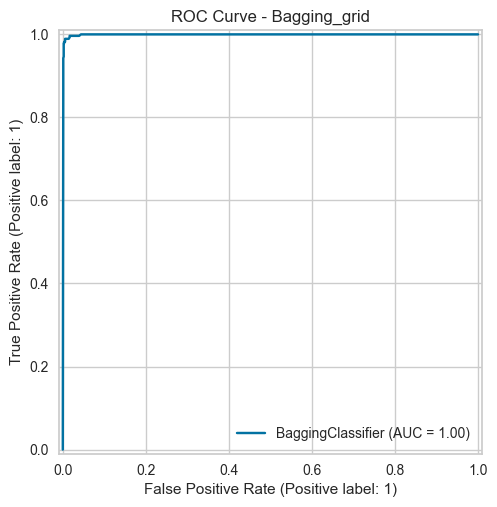

[I 2026-05-04 01:28:34,814] A new study created in memory with name: no-name-30e6f208-b249-4255-90e5-95741b7e03c5


    Train Metrics: {'Accuracy': '1.0000', 'Precision': '1.0000', 'Recall': '1.0000', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9925', 'Precision': '0.9925', 'Recall': '0.9925', 'F1': '0.99'}

Classification: RandomForest_optuna [Optuna]
        Optuna (10 trials)... 

[I 2026-05-04 01:28:35,750] Trial 0 finished with value: 0.980327868852459 and parameters: {'n_estimators': 137, 'max_depth': 10, 'min_samples_split': 2}. Best is trial 0 with value: 0.980327868852459.
[I 2026-05-04 01:28:36,531] Trial 1 finished with value: 0.9839708561020035 and parameters: {'n_estimators': 115, 'max_depth': 20, 'min_samples_split': 4}. Best is trial 1 with value: 0.9839708561020035.
[I 2026-05-04 01:28:37,227] Trial 2 finished with value: 0.9817850637522769 and parameters: {'n_estimators': 102, 'max_depth': 10, 'min_samples_split': 2}. Best is trial 1 with value: 0.9839708561020035.
[I 2026-05-04 01:28:38,044] Trial 3 finished with value: 0.980327868852459 and parameters: {'n_estimators': 118, 'max_depth': 20, 'min_samples_split': 3}. Best is trial 1 with value: 0.9839708561020035.
[I 2026-05-04 01:28:39,150] Trial 4 finished with value: 0.9825136612021858 and parameters: {'n_estimators': 161, 'max_depth': None, 'min_samples_split': 3}. Best is trial 1 with value: 0

  best=0.9840
    Applied best params for RandomForest_optuna
    Confusion Matrix:
 [[914   1]
 [  5 275]]


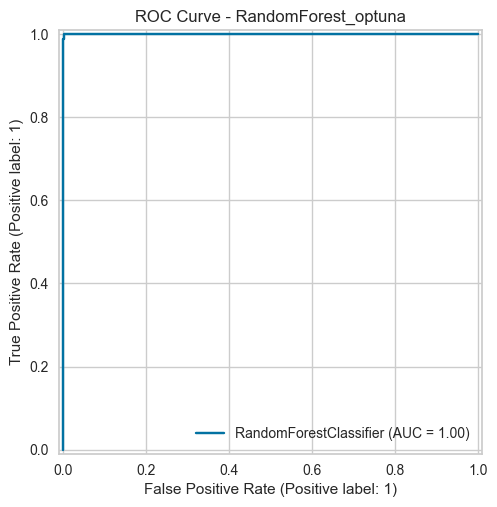

    Train Metrics: {'Accuracy': '0.9998', 'Precision': '0.9998', 'Recall': '0.9998', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9950', 'Precision': '0.9950', 'Recall': '0.9950', 'F1': '0.99'}

Classification: RandomForest_random [Random]
        Random Search (10 итераций)...   best=0.9840
    Applied best params for RandomForest_random
    Confusion Matrix:
 [[912   3]
 [  4 276]]


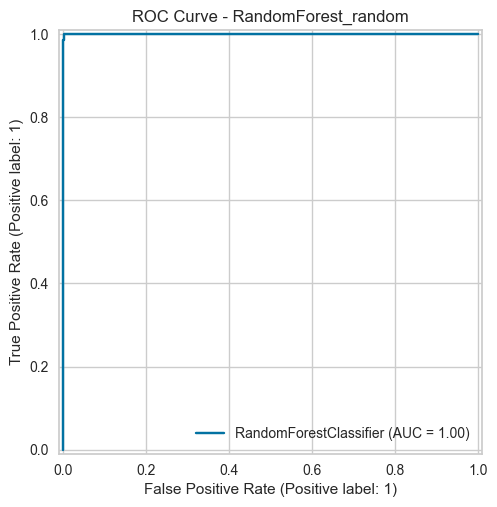

    Train Metrics: {'Accuracy': '1.0000', 'Precision': '1.0000', 'Recall': '1.0000', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9941', 'Precision': '0.9941', 'Recall': '0.9941', 'F1': '0.99'}

Classification: RandomForest_grid [Grid]
        Grid Search... (12 комбинаций, берем 20)...   best=0.9840
    Applied best params for RandomForest_grid
    Confusion Matrix:
 [[912   3]
 [  4 276]]


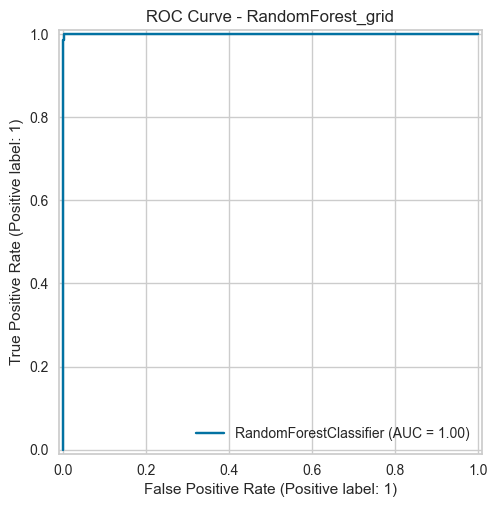

[I 2026-05-04 01:29:06,944] A new study created in memory with name: no-name-c4ff933a-2a4b-484c-8e5d-ee09fb9ce94d


    Train Metrics: {'Accuracy': '1.0000', 'Precision': '1.0000', 'Recall': '1.0000', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9941', 'Precision': '0.9941', 'Recall': '0.9941', 'F1': '0.99'}

Classification: GradientBoosting_optuna [Optuna]
        Optuna (10 trials)... 

[I 2026-05-04 01:29:09,905] Trial 0 finished with value: 0.981056466302368 and parameters: {'n_estimators': 137, 'learning_rate': 0.09664147012279758, 'max_depth': 5}. Best is trial 0 with value: 0.981056466302368.
[I 2026-05-04 01:29:12,041] Trial 1 finished with value: 0.9781420765027324 and parameters: {'n_estimators': 160, 'learning_rate': 0.05571040234647635, 'max_depth': 3}. Best is trial 0 with value: 0.981056466302368.
[I 2026-05-04 01:29:13,831] Trial 2 finished with value: 0.9795992714025502 and parameters: {'n_estimators': 105, 'learning_rate': 0.09114125527116833, 'max_depth': 4}. Best is trial 0 with value: 0.981056466302368.
[I 2026-05-04 01:29:17,609] Trial 3 finished with value: 0.9759562841530055 and parameters: {'n_estimators': 171, 'learning_rate': 0.05071851795705948, 'max_depth': 5}. Best is trial 0 with value: 0.981056466302368.
[I 2026-05-04 01:29:20,170] Trial 4 finished with value: 0.9795992714025502 and parameters: {'n_estimators': 184, 'learning_rate': 0.0579

  best=0.9811
    Applied best params for GradientBoosting_optuna
    Confusion Matrix:
 [[911   4]
 [  5 275]]


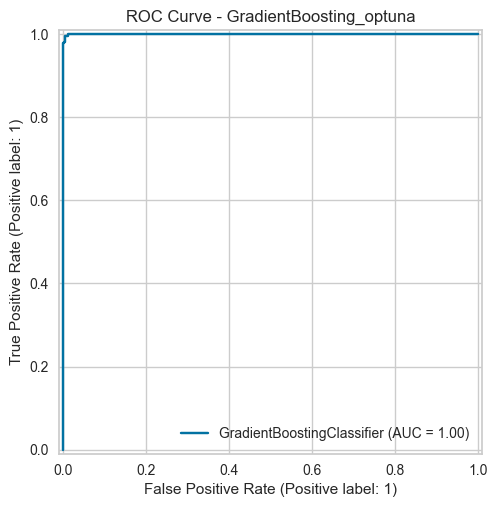

    Train Metrics: {'Accuracy': '1.0000', 'Precision': '1.0000', 'Recall': '1.0000', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9925', 'Precision': '0.9925', 'Recall': '0.9925', 'F1': '0.99'}

Classification: GradientBoosting_random [Random]
        Random Search (10 итераций)...   best=0.9818
    Applied best params for GradientBoosting_random
    Confusion Matrix:
 [[914   1]
 [  5 275]]


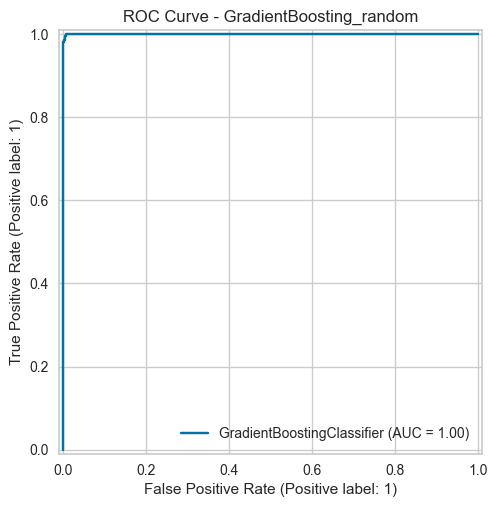

    Train Metrics: {'Accuracy': '1.0000', 'Precision': '1.0000', 'Recall': '1.0000', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9950', 'Precision': '0.9950', 'Recall': '0.9950', 'F1': '0.99'}

Classification: GradientBoosting_grid [Grid]
        Grid Search... (8 комбинаций, берем 20)...   best=0.9818
    Applied best params for GradientBoosting_grid
    Confusion Matrix:
 [[914   1]
 [  5 275]]


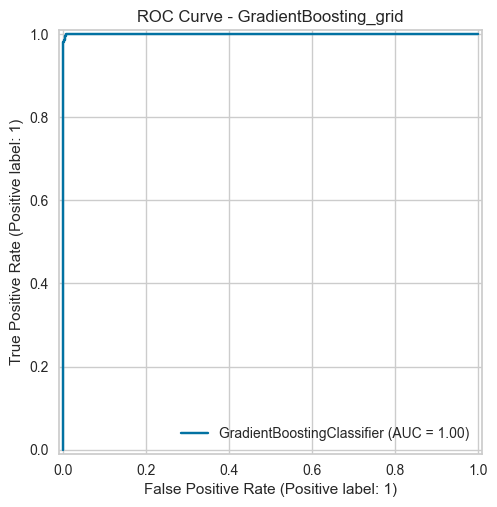

[I 2026-05-04 01:30:28,786] A new study created in memory with name: no-name-68a71b54-9894-4467-a3f5-b9f0a01d376d


    Train Metrics: {'Accuracy': '1.0000', 'Precision': '1.0000', 'Recall': '1.0000', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9950', 'Precision': '0.9950', 'Recall': '0.9950', 'F1': '0.99'}

Classification: AdaBoost_optuna [Optuna]
        Optuna (10 trials)... 

[I 2026-05-04 01:30:29,341] Trial 0 finished with value: 0.9759562841530055 and parameters: {'n_estimators': 69, 'learning_rate': 0.9664147012279757}. Best is trial 0 with value: 0.9759562841530055.
[I 2026-05-04 01:30:30,057] Trial 1 finished with value: 0.9781420765027322 and parameters: {'n_estimators': 87, 'learning_rate': 0.7571539027086853}. Best is trial 1 with value: 0.9781420765027322.
[I 2026-05-04 01:30:30,589] Trial 2 finished with value: 0.9744990892531875 and parameters: {'n_estimators': 57, 'learning_rate': 0.5570947094409952}. Best is trial 1 with value: 0.9781420765027322.
[I 2026-05-04 01:30:30,990] Trial 3 finished with value: 0.9730418943533697 and parameters: {'n_estimators': 52, 'learning_rate': 0.9114125527116832}. Best is trial 1 with value: 0.9781420765027322.
[I 2026-05-04 01:30:31,579] Trial 4 finished with value: 0.9737704918032787 and parameters: {'n_estimators': 80, 'learning_rate': 0.8168100814185651}. Best is trial 1 with value: 0.9781420765027322.
[I 20

  best=0.9796
    Applied best params for AdaBoost_optuna
    Confusion Matrix:
 [[909   6]
 [  5 275]]


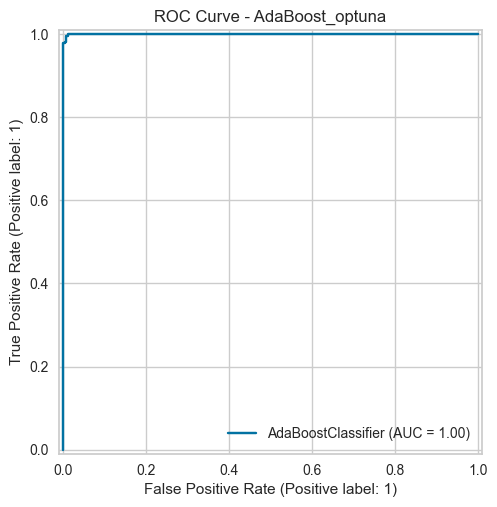

    Train Metrics: {'Accuracy': '0.9974', 'Precision': '0.9975', 'Recall': '0.9974', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9908', 'Precision': '0.9908', 'Recall': '0.9908', 'F1': '0.99'}

Classification: AdaBoost_random [Random]
        Random Search (10 итераций)...   best=0.9818
    Applied best params for AdaBoost_random
    Confusion Matrix:
 [[910   5]
 [  4 276]]


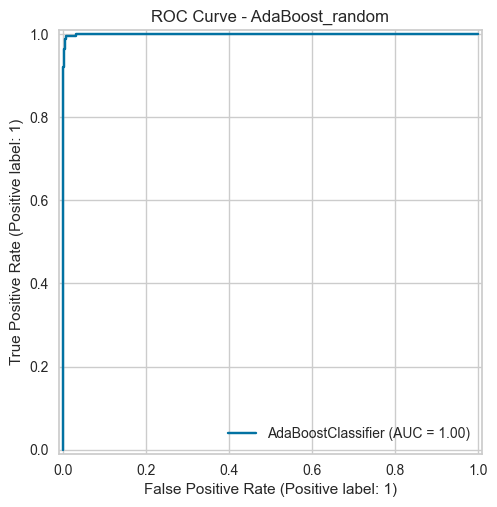

    Train Metrics: {'Accuracy': '1.0000', 'Precision': '1.0000', 'Recall': '1.0000', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9925', 'Precision': '0.9925', 'Recall': '0.9925', 'F1': '0.99'}

Classification: AdaBoost_grid [Grid]
        Grid Search... (4 комбинаций, берем 20)...   best=0.9818
    Applied best params for AdaBoost_grid
    Confusion Matrix:
 [[910   5]
 [  4 276]]


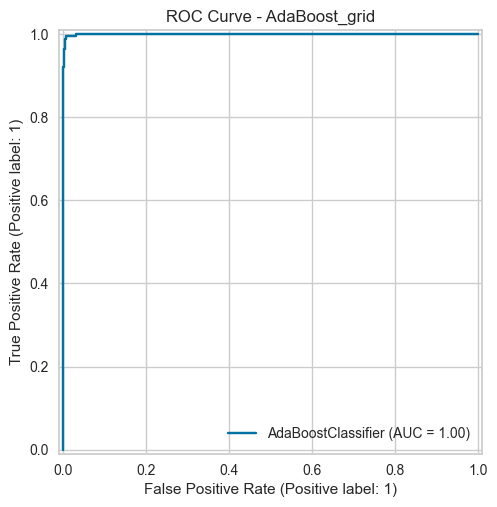

[I 2026-05-04 01:30:43,293] A new study created in memory with name: no-name-a0784276-d4f6-4cf7-b4a9-74c6d75967e8


    Train Metrics: {'Accuracy': '1.0000', 'Precision': '1.0000', 'Recall': '1.0000', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9925', 'Precision': '0.9925', 'Recall': '0.9925', 'F1': '0.99'}

Classification: XGBoost_optuna [Optuna]
        Optuna (10 trials)... 

[I 2026-05-04 01:30:43,563] Trial 0 finished with value: 0.9817850637522769 and parameters: {'n_estimators': 137, 'max_depth': 5, 'learning_rate': 0.0830466536774918}. Best is trial 0 with value: 0.9817850637522769.
[I 2026-05-04 01:30:43,709] Trial 1 finished with value: 0.9774134790528233 and parameters: {'n_estimators': 160, 'max_depth': 3, 'learning_rate': 0.05570947094409951}. Best is trial 0 with value: 0.9817850637522769.
[I 2026-05-04 01:30:43,869] Trial 2 finished with value: 0.9832422586520947 and parameters: {'n_estimators': 105, 'max_depth': 5, 'learning_rate': 0.07584442335012195}. Best is trial 2 with value: 0.9832422586520947.
[I 2026-05-04 01:30:44,029] Trial 3 finished with value: 0.980327868852459 and parameters: {'n_estimators': 171, 'max_depth': 3, 'learning_rate': 0.09793590997167137}. Best is trial 2 with value: 0.9832422586520947.
[I 2026-05-04 01:30:44,190] Trial 4 finished with value: 0.9774134790528233 and parameters: {'n_estimators': 184, 'max_depth': 3, 'lea

  best=0.9832
    Applied best params for XGBoost_optuna
    Confusion Matrix:
 [[914   1]
 [  6 274]]


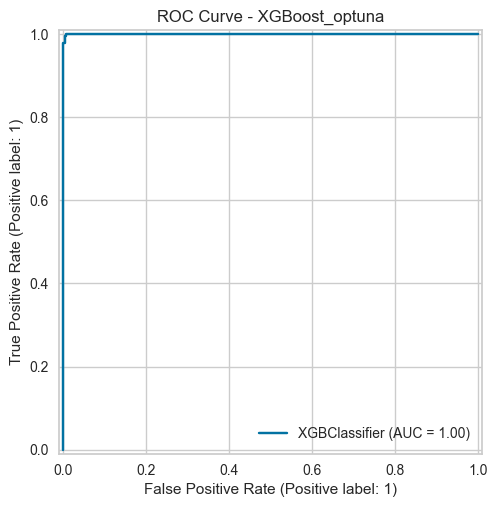

    Train Metrics: {'Accuracy': '1.0000', 'Precision': '1.0000', 'Recall': '1.0000', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9941', 'Precision': '0.9942', 'Recall': '0.9941', 'F1': '0.99'}

Classification: XGBoost_random [Random]
        Random Search (10 итераций)...   best=0.9847
    Applied best params for XGBoost_random
    Confusion Matrix:
 [[912   3]
 [  6 274]]


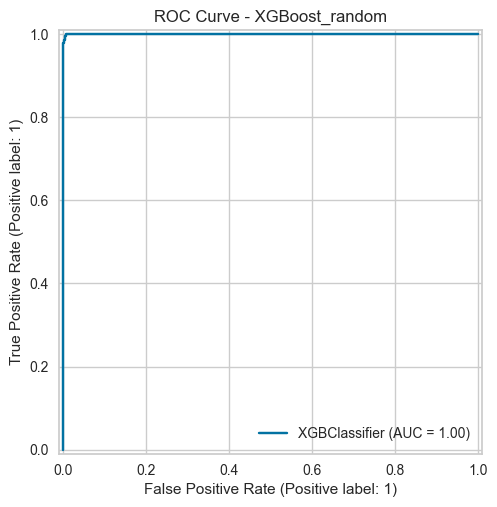

    Train Metrics: {'Accuracy': '1.0000', 'Precision': '1.0000', 'Recall': '1.0000', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9925', 'Precision': '0.9925', 'Recall': '0.9925', 'F1': '0.99'}

Classification: XGBoost_grid [Grid]
        Grid Search... (8 комбинаций, берем 20)...   best=0.9847
    Applied best params for XGBoost_grid
    Confusion Matrix:
 [[912   3]
 [  6 274]]


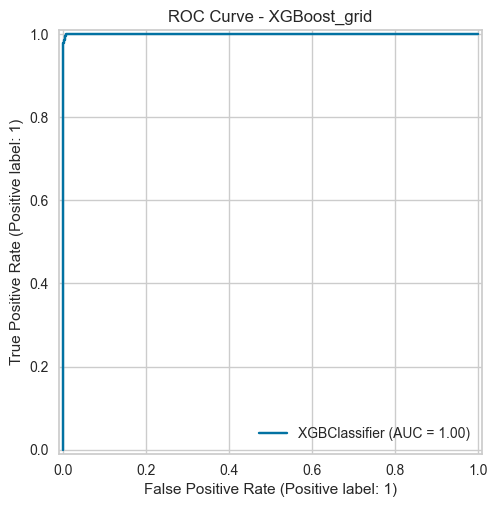

[I 2026-05-04 01:30:48,541] A new study created in memory with name: no-name-cbcadeb6-7e29-42b6-92e8-94591f8a9f9b


    Train Metrics: {'Accuracy': '1.0000', 'Precision': '1.0000', 'Recall': '1.0000', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9925', 'Precision': '0.9925', 'Recall': '0.9925', 'F1': '0.99'}

Classification: LightGBM_optuna [Optuna]
        Optuna (10 trials)... 

[I 2026-05-04 01:30:49,063] Trial 0 finished with value: 0.9846994535519125 and parameters: {'n_estimators': 137, 'max_depth': 5, 'learning_rate': 0.0830466536774918, 'num_leaves': 42}. Best is trial 0 with value: 0.9846994535519125.
[I 2026-05-04 01:30:50,016] Trial 1 finished with value: 0.9788706739526412 and parameters: {'n_estimators': 115, 'max_depth': 0, 'learning_rate': 0.052054096619994904, 'num_leaves': 48}. Best is trial 0 with value: 0.9846994535519125.
[I 2026-05-04 01:30:50,418] Trial 2 finished with value: 0.9766848816029144 and parameters: {'n_estimators': 160, 'max_depth': 3, 'learning_rate': 0.05071851795705948, 'num_leaves': 50}. Best is trial 0 with value: 0.9846994535519125.
[I 2026-05-04 01:30:51,298] Trial 3 finished with value: 0.9817850637522769 and parameters: {'n_estimators': 184, 'max_depth': 0, 'learning_rate': 0.05671589285948462, 'num_leaves': 34}. Best is trial 0 with value: 0.9846994535519125.
[I 2026-05-04 01:30:51,458] Trial 4 finished with value: 0.9

  best=0.9847
    Applied best params for LightGBM_optuna
    Confusion Matrix:
 [[914   1]
 [  3 277]]


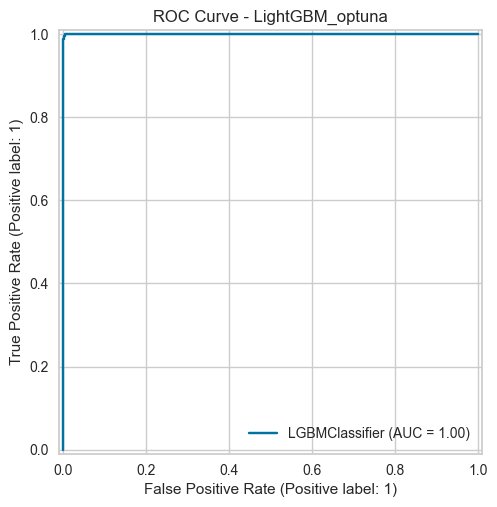

    Train Metrics: {'Accuracy': '1.0000', 'Precision': '1.0000', 'Recall': '1.0000', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9967', 'Precision': '0.9967', 'Recall': '0.9967', 'F1': '1.00'}

Classification: LightGBM_random [Random]
        Random Search (10 итераций)...   best=0.9854
    Applied best params for LightGBM_random
    Confusion Matrix:
 [[914   1]
 [  4 276]]


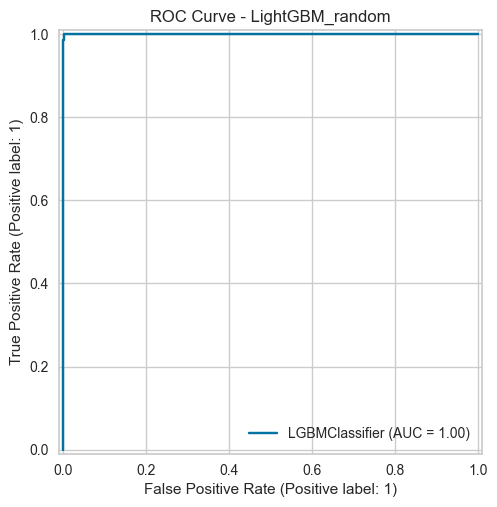

    Train Metrics: {'Accuracy': '1.0000', 'Precision': '1.0000', 'Recall': '1.0000', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9958', 'Precision': '0.9958', 'Recall': '0.9958', 'F1': '1.00'}

Classification: LightGBM_grid [Grid]
        Grid Search... (16 комбинаций, берем 20)...   best=0.9854
    Applied best params for LightGBM_grid
    Confusion Matrix:
 [[914   1]
 [  4 276]]


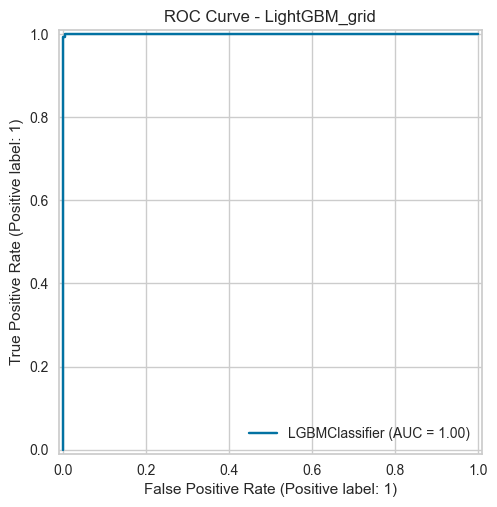

[I 2026-05-04 01:31:15,029] A new study created in memory with name: no-name-0ff5a713-a48c-4739-bf41-dc745dcb18a0


    Train Metrics: {'Accuracy': '1.0000', 'Precision': '1.0000', 'Recall': '1.0000', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9958', 'Precision': '0.9958', 'Recall': '0.9958', 'F1': '1.00'}

Classification: CatBoost_optuna [Optuna]
        Optuna (10 trials)... 

[I 2026-05-04 01:31:16,769] Trial 0 finished with value: 0.9766848816029142 and parameters: {'iterations': 137, 'depth': 6, 'learning_rate': 0.0830466536774918}. Best is trial 0 with value: 0.9766848816029142.
[I 2026-05-04 01:31:18,180] Trial 1 finished with value: 0.9744990892531877 and parameters: {'iterations': 160, 'depth': 4, 'learning_rate': 0.05570947094409951}. Best is trial 0 with value: 0.9766848816029142.
[I 2026-05-04 01:31:19,797] Trial 2 finished with value: 0.9752276867030965 and parameters: {'iterations': 105, 'depth': 6, 'learning_rate': 0.07584442335012195}. Best is trial 0 with value: 0.9766848816029142.
[I 2026-05-04 01:31:20,480] Trial 3 finished with value: 0.9788706739526412 and parameters: {'iterations': 171, 'depth': 4, 'learning_rate': 0.09793590997167137}. Best is trial 3 with value: 0.9788706739526412.
[I 2026-05-04 01:31:21,270] Trial 4 finished with value: 0.9752276867030965 and parameters: {'iterations': 184, 'depth': 4, 'learning_rate': 0.05671589285948

  best=0.9789
    Applied best params for CatBoost_optuna
    Confusion Matrix:
 [[912   3]
 [  4 276]]


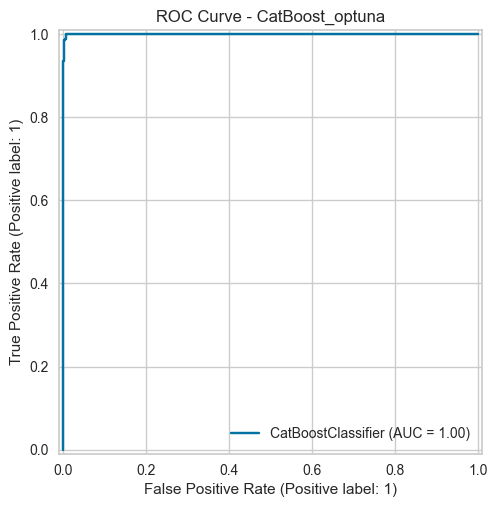

    Train Metrics: {'Accuracy': '0.9964', 'Precision': '0.9964', 'Recall': '0.9964', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9941', 'Precision': '0.9941', 'Recall': '0.9941', 'F1': '0.99'}

Classification: CatBoost_random [Random]
        Random Search (10 итераций)...   best=0.9847
    Applied best params for CatBoost_random
    Confusion Matrix:
 [[912   3]
 [  3 277]]


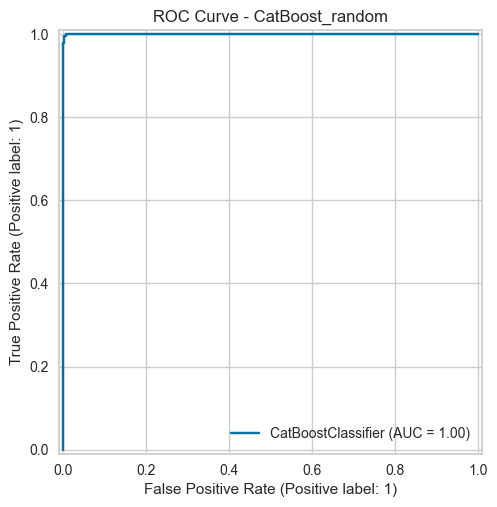

    Train Metrics: {'Accuracy': '1.0000', 'Precision': '1.0000', 'Recall': '1.0000', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9950', 'Precision': '0.9950', 'Recall': '0.9950', 'F1': '0.99'}

Classification: CatBoost_grid [Grid]
        Grid Search... (8 комбинаций, берем 20)...   best=0.9847
    Applied best params for CatBoost_grid
    Confusion Matrix:
 [[912   3]
 [  3 277]]


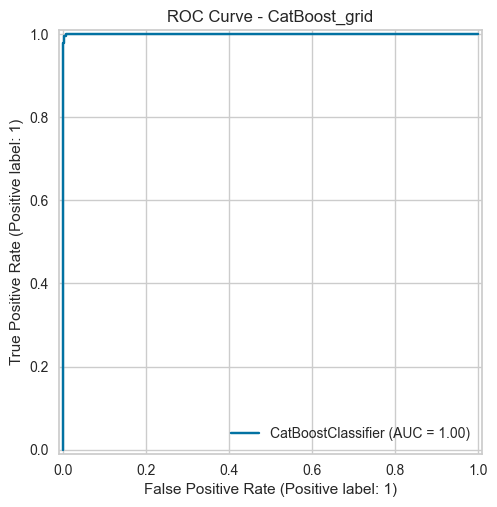

[I 2026-05-04 01:31:43,584] A new study created in memory with name: no-name-ed8790f2-5530-4ad3-8365-72024251325b


    Train Metrics: {'Accuracy': '1.0000', 'Precision': '1.0000', 'Recall': '1.0000', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9950', 'Precision': '0.9950', 'Recall': '0.9950', 'F1': '0.99'}

Classification: Stacking_optuna [Optuna]
        Optuna (10 trials)... 

[I 2026-05-04 01:31:51,242] Trial 0 finished with value: 0.9861566484517302 and parameters: {}. Best is trial 0 with value: 0.9861566484517302.
[I 2026-05-04 01:31:58,696] Trial 1 finished with value: 0.9861566484517302 and parameters: {}. Best is trial 0 with value: 0.9861566484517302.
[I 2026-05-04 01:32:06,055] Trial 2 finished with value: 0.9861566484517302 and parameters: {}. Best is trial 0 with value: 0.9861566484517302.
[I 2026-05-04 01:32:13,204] Trial 3 finished with value: 0.9861566484517302 and parameters: {}. Best is trial 0 with value: 0.9861566484517302.
[I 2026-05-04 01:32:20,623] Trial 4 finished with value: 0.9861566484517302 and parameters: {}. Best is trial 0 with value: 0.9861566484517302.
[I 2026-05-04 01:32:28,145] Trial 5 finished with value: 0.9861566484517302 and parameters: {}. Best is trial 0 with value: 0.9861566484517302.
[I 2026-05-04 01:32:35,559] Trial 6 finished with value: 0.9861566484517302 and parameters: {}. Best is trial 0 with value: 0.9861566484

  best=0.9862
    Applied best params for Stacking_optuna
    Confusion Matrix:
 [[914   1]
 [  5 275]]


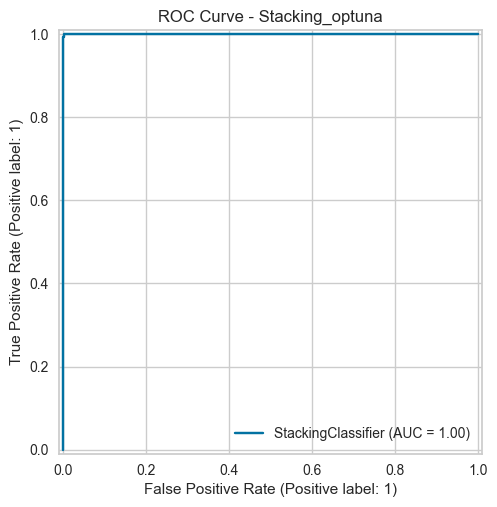

    Train Metrics: {'Accuracy': '1.0000', 'Precision': '1.0000', 'Recall': '1.0000', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9950', 'Precision': '0.9950', 'Recall': '0.9950', 'F1': '0.99'}

Classification: Stacking_random [Random]
        Random Search (10 итераций)...   best=0.9862
    Applied best params for Stacking_random
    Confusion Matrix:
 [[914   1]
 [  5 275]]


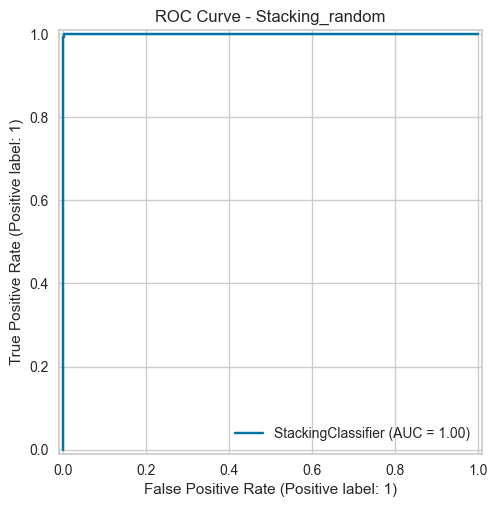

    Train Metrics: {'Accuracy': '1.0000', 'Precision': '1.0000', 'Recall': '1.0000', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9950', 'Precision': '0.9950', 'Recall': '0.9950', 'F1': '0.99'}

Classification: Stacking_grid [Grid]
        Grid Search... (1 комбинаций, берем 20)...   best=0.9862
    Applied best params for Stacking_grid
    Confusion Matrix:
 [[914   1]
 [  5 275]]


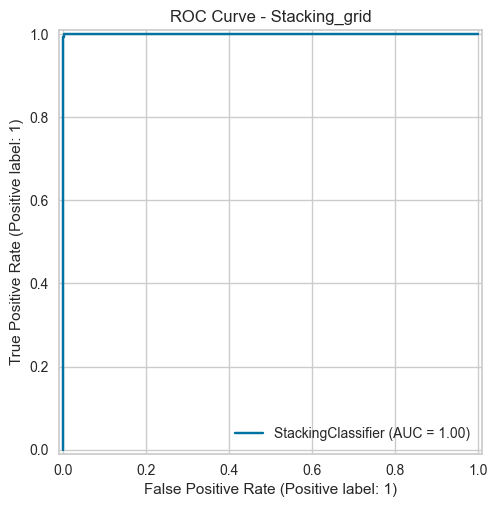

    Train Metrics: {'Accuracy': '1.0000', 'Precision': '1.0000', 'Recall': '1.0000', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9950', 'Precision': '0.9950', 'Recall': '0.9950', 'F1': '0.99'}


In [22]:
train_evaluate_loop_optimized(
    cls_models, 
    X_train_bal_wine, y_train_bal_wine, 
    X_val_wine, y_val_wine, 
    X_test_wine, y_test_wine, 
    cv_wine, 
    'Classification', 
    calculate_metrics_cls, 
    cls_results_wine
)

In [23]:
train_evaluate_loop_optimized(
    reg_models, 
    X_train_diamonds, y_train_diamonds, 
    X_val_diamonds, y_val_diamonds, 
    X_test_diamonds, y_test_diamonds, 
    cv_diamonds, 
    'Regression', 
    calculate_metrics_reg, 
    reg_results_diamonds
)

[I 2026-05-04 01:34:00,434] A new study created in memory with name: no-name-1c2ec75c-9e77-4a6b-9630-aee5d9ee4ee8



Regression: DecisionTree_optuna [Optuna]
        Optuna (10 trials)... 

[I 2026-05-04 01:34:00,747] Trial 0 finished with value: 0.9676795264434466 and parameters: {'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.9676795264434466.
[I 2026-05-04 01:34:01,036] Trial 1 finished with value: 0.970874913026682 and parameters: {'max_depth': None, 'min_samples_split': 7, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.970874913026682.
[I 2026-05-04 01:34:01,346] Trial 2 finished with value: 0.9644303716078445 and parameters: {'max_depth': 20, 'min_samples_split': 3, 'min_samples_leaf': 1}. Best is trial 1 with value: 0.970874913026682.
[I 2026-05-04 01:34:01,663] Trial 3 finished with value: 0.9677698687120104 and parameters: {'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 2}. Best is trial 1 with value: 0.970874913026682.
[I 2026-05-04 01:34:01,918] Trial 4 finished with value: 0.9727193628018476 and parameters: {'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 2}. Best is trial 4 wi

  best=0.9735
    Applied best params for DecisionTree_optuna
    Train Metrics: {'R2': '0.98', 'RMSE': '534.5021', 'MAE': '292.3287', 'MSE': '285692.5362'}
    Test Metrics: {'R2': '0.97', 'RMSE': '638.0269', 'MAE': '336.5166', 'MSE': '407078.3620'}

Regression: DecisionTree_random [Random]
        Random Search (10 итераций)...   best=0.9735
    Applied best params for DecisionTree_random
    Train Metrics: {'R2': '0.98', 'RMSE': '534.5021', 'MAE': '292.3287', 'MSE': '285692.5362'}
    Test Metrics: {'R2': '0.97', 'RMSE': '638.0269', 'MAE': '336.5166', 'MSE': '407078.3620'}

Regression: DecisionTree_grid [Grid]
        Grid Search... (27 комбинаций, берем 20)...   best=0.9735
    Applied best params for DecisionTree_grid


[I 2026-05-04 01:34:06,660] A new study created in memory with name: no-name-b2abc838-aac8-41ec-9393-5f87bb5cba82


...

  best=0.9800
    Applied best params for CatBoost_optuna
    Train Metrics: {'R2': '0.98', 'RMSE': '531.8808', 'MAE': '295.3698', 'MSE': '282897.1554'}
    Test Metrics: {'R2': '0.98', 'RMSE': '560.6456', 'MAE': '303.8732', 'MSE': '314323.4430'}

Regression: CatBoost_random [Random]
        Random Search (10 итераций)...   best=0.9813
    Applied best params for CatBoost_random
    Train Metrics: {'R2': '0.98', 'RMSE': '495.2369', 'MAE': '277.1439', 'MSE': '245259.5885'}
    Test Metrics: {'R2': '0.98', 'RMSE': '543.3311', 'MAE': '291.1469', 'MSE': '295208.6382'}

Regression: CatBoost_grid [Grid]
        Grid Search... (8 комбинаций, берем 20)...   best=0.9813
    Applied best params for CatBoost_grid


[I 2026-05-04 01:51:36,668] A new study created in memory with name: no-name-92a5d71b-a5e2-4606-b96f-03b95288cecd


    Train Metrics: {'R2': '0.98', 'RMSE': '495.2369', 'MAE': '277.1439', 'MSE': '245259.5885'}
    Test Metrics: {'R2': '0.98', 'RMSE': '543.3311', 'MAE': '291.1469', 'MSE': '295208.6382'}

Regression: Stacking_optuna [Optuna]
        Optuna (10 trials)... 

[I 2026-05-04 01:52:47,718] Trial 0 finished with value: 0.9822781441365647 and parameters: {}. Best is trial 0 with value: 0.9822781441365647.
[I 2026-05-04 01:54:44,623] Trial 1 finished with value: 0.9822781441365647 and parameters: {}. Best is trial 0 with value: 0.9822781441365647.
[I 2026-05-04 01:55:55,398] Trial 2 finished with value: 0.9822781441365647 and parameters: {}. Best is trial 0 with value: 0.9822781441365647.
[I 2026-05-04 01:56:59,527] Trial 3 finished with value: 0.9822781441365647 and parameters: {}. Best is trial 0 with value: 0.9822781441365647.
[I 2026-05-04 01:58:09,298] Trial 4 finished with value: 0.9822781441365647 and parameters: {}. Best is trial 0 with value: 0.9822781441365647.
[I 2026-05-04 01:59:13,600] Trial 5 finished with value: 0.9822781441365647 and parameters: {}. Best is trial 0 with value: 0.9822781441365647.
[I 2026-05-04 02:00:17,115] Trial 6 finished with value: 0.9822781441365647 and parameters: {}. Best is trial 0 with value: 0.9822781441

  best=0.9823
    Applied best params for Stacking_optuna
    Train Metrics: {'R2': '0.99', 'RMSE': '340.5366', 'MAE': '188.3358', 'MSE': '115965.2076'}
    Test Metrics: {'R2': '0.98', 'RMSE': '523.4649', 'MAE': '263.0419', 'MSE': '274015.5264'}

Regression: Stacking_random [Random]
        Random Search (10 итераций)...   best=0.9823
    Applied best params for Stacking_random
    Train Metrics: {'R2': '0.99', 'RMSE': '340.5366', 'MAE': '188.3358', 'MSE': '115965.2076'}
    Test Metrics: {'R2': '0.98', 'RMSE': '523.4649', 'MAE': '263.0419', 'MSE': '274015.5264'}

Regression: Stacking_grid [Grid]
        Grid Search... (1 комбинаций, берем 20)...   best=0.9823
    Applied best params for Stacking_grid
    Train Metrics: {'R2': '0.99', 'RMSE': '340.5366', 'MAE': '188.3358', 'MSE': '115965.2076'}
    Test Metrics: {'R2': '0.98', 'RMSE': '523.4649', 'MAE': '263.0419', 'MSE': '274015.5264'}


In [24]:
print(" Запуск PyCaret для задачи КЛАССИФИКАЦИИ (Wine)...")
setup_cls(data=pd.concat([X_train_bal_wine, y_train_bal_wine], axis=1), 
          target='type', train_size=0.6, fold=5, verbose=False)

best_cls_pycaret = compare_cls(sort='F1', n_select=10)
pycaret_cls_results = pull_cls()

cls_cols = [c for c in ['Model', 'Accuracy', 'AUC', 'Recall', 'Prec.', 'Precision', 'F1', 'F1 Score', 'Kappa'] 
            if c in pycaret_cls_results.columns]
display(pycaret_cls_results[cls_cols])

 Запуск PyCaret для задачи КЛАССИФИКАЦИИ (Wine)...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.9970,0.9983,0.9945,0.9994,0.9970,0.9939,0.9939,0.0640
catboost,CatBoost Classifier,0.9967,0.9987,0.9945,0.9988,0.9966,0.9933,0.9933,1.1660
ridge,Ridge Classifier,0.9961,0.9988,0.9945,0.9976,0.9960,0.9921,0.9921,0.0100
rf,Random Forest Classifier,0.9961,0.9987,0.9927,0.9994,0.9960,0.9921,0.9921,0.0880
lda,Linear Discriminant Analysis,0.9961,0.9988,0.9945,0.9976,0.9960,0.9921,0.9921,0.0100
lr,Logistic Regression,0.9954,0.9989,0.9939,0.9970,0.9954,0.9909,0.9909,0.6920
qda,Quadratic Discriminant Analysis,0.9954,0.9987,0.9951,0.9958,0.9954,0.9909,0.9909,0.0140
gbc,Gradient Boosting Classifier,0.9945,0.9982,0.9921,0.9970,0.9945,0.9891,0.9891,0.1800
nb,Naive Bayes,0.9942,0.9982,0.9933,0.9952,0.9942,0.9885,0.9885,0.3680
lightgbm,Light Gradient Boosting Machine,0.9942,0.9984,0.9915,0.9970,0.9942,0.9885,0.9885,0.1080


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa
et,Extra Trees Classifier,0.9970,0.9983,0.9945,0.9994,0.9970,0.9939
catboost,CatBoost Classifier,0.9967,0.9987,0.9945,0.9988,0.9966,0.9933
ridge,Ridge Classifier,0.9961,0.9988,0.9945,0.9976,0.9960,0.9921
rf,Random Forest Classifier,0.9961,0.9987,0.9927,0.9994,0.9960,0.9921
lda,Linear Discriminant Analysis,0.9961,0.9988,0.9945,0.9976,0.9960,0.9921
lr,Logistic Regression,0.9954,0.9989,0.9939,0.9970,0.9954,0.9909
qda,Quadratic Discriminant Analysis,0.9954,0.9987,0.9951,0.9958,0.9954,0.9909
gbc,Gradient Boosting Classifier,0.9945,0.9982,0.9921,0.9970,0.9945,0.9891
nb,Naive Bayes,0.9942,0.9982,0.9933,0.9952,0.9942,0.9885
lightgbm,Light Gradient Boosting Machine,0.9942,0.9984,0.9915,0.9970,0.9942,0.9885


Pycaret демонстрирует очень схожие метрики с натренированными моделями

In [25]:
print("\n\n Запуск PyCaret для задачи РЕГРЕССИИ (Diamonds)...")
setup_reg(data=pd.concat([X_train_diamonds, y_train_diamonds], axis=1), 
          target='price', train_size=0.8, fold=5, verbose=False)

best_reg_pycaret = compare_reg(sort='R2', n_select=10)
pycaret_reg_results = pull_reg()

reg_cols = [c for c in ['Model', 'MAE', 'MSE', 'RMSE', 'R2', 'RMSLE'] 
            if c in pycaret_reg_results.columns]
display(pycaret_reg_results[reg_cols])



 Запуск PyCaret для задачи РЕГРЕССИИ (Diamonds)...


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
catboost,CatBoost Regressor,278.0573,300552.9282,548.0998,0.9812,0.0995,0.0748,1.5620
lightgbm,Light Gradient Boosting Machine,286.5149,306434.7346,553.3150,0.9809,0.1062,0.0815,0.1100
et,Extra Trees Regressor,280.6184,316612.0288,562.5055,0.9802,0.0948,0.0696,0.6660
rf,Random Forest Regressor,285.4255,327163.8686,571.7170,0.9796,0.0944,0.0692,1.0120
xgboost,Extreme Gradient Boosting,289.6063,328005.6974,572.5705,0.9795,0.1006,0.0735,0.0580
gbr,Gradient Boosting Regressor,347.9038,400032.1105,632.4491,0.9750,0.1565,0.1088,0.4380
dt,Decision Tree Regressor,383.4713,594252.7920,770.4655,0.9629,0.1312,0.0925,0.0400
knn,K Neighbors Regressor,412.7876,602745.2423,776.2307,0.9624,0.1529,0.1179,0.0700
ada,AdaBoost Regressor,884.3026,1299152.7710,1139.7026,0.9188,0.4225,0.4458,0.2260
lasso,Lasso Regression,807.3988,1477957.9911,1215.5783,0.9078,0.6502,0.4411,0.0280


,Model,MAE,MSE,RMSE,R2,RMSLE
catboost,CatBoost Regressor,278.0573,3.005529e+05,548.0998,0.9812,0.0995
lightgbm,Light Gradient Boosting Machine,286.5149,3.064347e+05,553.3150,0.9809,0.1062
et,Extra Trees Regressor,280.6184,3.166120e+05,562.5055,0.9802,0.0948
rf,Random Forest Regressor,285.4255,3.271639e+05,571.7170,0.9796,0.0944
xgboost,Extreme Gradient Boosting,289.6063,3.280057e+05,572.5705,0.9795,0.1006
gbr,Gradient Boosting Regressor,347.9038,4.000321e+05,632.4491,0.9750,0.1565
dt,Decision Tree Regressor,383.4713,5.942528e+05,770.4655,0.9629,0.1312
knn,K Neighbors Regressor,412.7876,6.027452e+05,776.2307,0.9624,0.1529
ada,AdaBoost Regressor,884.3026,1.299153e+06,1139.7026,0.9188,0.4225
lasso,Lasso Regression,807.3988,1.477958e+06,1215.5783,0.9078,0.6502


Pycaret демонстрирует очень схожие метрики с натренированными моделями

In [26]:
def build_and_display_tables(results_list, task_name, metrics_order):
    print(f"{task_name}")
    df = pd.DataFrame(results_list).set_index('Algorithm')
    df.columns = pd.MultiIndex.from_tuples(df.columns)
    cols_1 = [c for c in df.columns if c[0] in ['Train Data', 'Test Data']]
    cols_1_sorted = sorted(cols_1, key=lambda c: (0 if c[0]=='Train Data' else 1, metrics_order.index(c[1])))
    table_1 = df[cols_1_sorted]
    display(table_1)
    
    cols_2 = [c for c in df.columns if c[0] in ['Test Data', 'K-Fold CV']]
    cols_2_renamed = [('Метод hold-out', c[1]) if c[0] == 'Test Data' else c for c in cols_2]
    cols_2_sorted = sorted(cols_2_renamed, key=lambda c: (
        0 if c[0]=='Метод hold-out' else 1, 
        metrics_order.index(c[1].split(' (')[0])
    ))
    table_2 = df[[c for c in df.columns if c[0] in ['Test Data', 'K-Fold CV']]].copy()
    table_2.columns = pd.MultiIndex.from_tuples(cols_2_sorted)
    display(table_2)
    
    return table_1, table_2

cls_metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
reg_metrics = ['R2', 'RMSE', 'MAE', 'MSE']

tbl1_cls, tbl2_cls = build_and_display_tables(cls_results_wine, "Классификация (Wine)", cls_metrics)
tbl1_reg, tbl2_reg = build_and_display_tables(reg_results_diamonds, "Регрессия (Diamonds)", reg_metrics)

Классификация (Wine)


Train Data                         Test Data  \
                          Accuracy Precision  Recall    F1  Accuracy   
Algorithm                                                              
DecisionTree                1.0000    1.0000  1.0000  1.00    0.9874   
Bagging                     0.9989    0.9989  0.9989  1.00    0.9933   
RandomForest                1.0000    1.0000  1.0000  1.00    0.9967   
GradientBoosting            0.9995    0.9995  0.9995  1.00    0.9933   
AdaBoost                    0.9973    0.9973  0.9973  1.00    0.9933   
XGBoost                     1.0000    1.0000  1.0000  1.00    0.9941   
LightGBM                    1.0000    1.0000  1.0000  1.00    0.9967   
CatBoost                    1.0000    1.0000  1.0000  1.00    0.9950   
Stacking                    1.0000    1.0000  1.0000  1.00    0.9950   
DecisionTree_optuna         0.9967    0.9967  0.9967  1.00    0.9866   
DecisionTree_random         0.9971    0.9971  0.9971  1.00    0.9874   
DecisionTree_grid           0.9971    0.9971  0.9971  1.00    0.9874   
Bagging_optuna              1.0000    1.0000  1.0000  1.00    0.9925   
Bagging_random              1.0000    1.0000  1.0000  1.00    0.9925   
Bagging_grid                1.0000    1.0000  1.0000  1.00    0.9925   
RandomForest_optuna         0.9998    0.9998  0.9998  1.00    0.9950   
RandomForest_random         1.0000    1.0000  1.0000  1.00    0.9941   
RandomForest_grid           1.0000    1.0000  1.0000  1.00    0.9941   
GradientBoosting_optuna     1.0000    1.0000  1.0000  1.00    0.9925   
GradientBoosting_random     1.0000    1.0000  1.0000  1.00    0.9950   
GradientBoosting_grid       1.0000    1.0000  1.0000  1.00    0.9950   
AdaBoost_optuna             0.9974    0.9975  0.9974  1.00    0.9908   
AdaBoost_random             1.0000    1.0000  1.0000  1.00    0.9925   
AdaBoost_grid               1.0000    1.0000  1.0000  1.00    0.9925   
XGBoost_optuna              1.0000    1.0000  1.0000  1.00    0.9941   
XGBoost_random              1.0000    1.0000  1.0000  1.00    0.9925   
XGBoost_grid                1.0000    1.0000  1.0000  1.00    0.9925   
LightGBM_optuna             1.0000    1.0000  1.0000  1.00    0.9967   
LightGBM_random             1.0000    1.0000  1.0000  1.00    0.9958   
LightGBM_grid               1.0000    1.0000  1.0000  1.00    0.9958   
CatBoost_optuna             0.9964    0.9964  0.9964  1.00    0.9941   
CatBoost_random             1.0000    1.0000  1.0000  1.00    0.9950   
CatBoost_grid               1.0000    1.0000  1.0000  1.00    0.9950   
Stacking_optuna             1.0000    1.0000  1.0000  1.00    0.9950   
Stacking_random             1.0000    1.0000  1.0000  1.00    0.9950   
Stacking_grid               1.0000    1.0000  1.0000  1.00    0.9950   

                                                 
                        Precision  Recall    F1  
Algorithm                                        
DecisionTree               0.9875  0.9874  0.99  
Bagging                    0.9933  0.9933  0.99  
RandomForest               0.9967  0.9967  1.00  
GradientBoosting           0.9933  0.9933  0.99  
AdaBoost                   0.9934  0.9933  0.99  
XGBoost                    0.9941  0.9941  0.99  
LightGBM                   0.9967  0.9967  1.00  
CatBoost                   0.9950  0.9950  0.99  
Stacking                   0.9950  0.9950  0.99  
DecisionTree_optuna        0.9866  0.9866  0.99  
DecisionTree_random        0.9874  0.9874  0.99  
DecisionTree_grid          0.9874  0.9874  0.99  
Bagging_optuna             0.9925  0.9925  0.99  
Bagging_random             0.9925  0.9925  0.99  
Bagging_grid               0.9925  0.9925  0.99  
RandomForest_optuna        0.9950  0.9950  0.99  
RandomForest_random        0.9941  0.9941  0.99  
RandomForest_grid          0.9941  0.9941  0.99  
GradientBoosting_optuna    0.9925  0.9925  0.99  
GradientBoosting_random    0.9950  0.9950  0.99  
GradientBoosting_grid      0.9950  0.9950  0.99  
AdaBoost_optuna

Метод hold-out                          \
                              Accuracy Precision  Recall    F1   
Algorithm                                                        
DecisionTree                    0.9874    0.9875  0.9874  0.99   
Bagging                         0.9933    0.9933  0.9933  0.99   
RandomForest                    0.9967    0.9967  0.9967  1.00   
GradientBoosting                0.9933    0.9933  0.9933  0.99   
AdaBoost                        0.9933    0.9934  0.9933  0.99   
XGBoost                         0.9941    0.9941  0.9941  0.99   
LightGBM                        0.9967    0.9967  0.9967  1.00   
CatBoost                        0.9950    0.9950  0.9950  0.99   
Stacking                        0.9950    0.9950  0.9950  0.99   
DecisionTree_optuna             0.9866    0.9866  0.9866  0.99   
DecisionTree_random             0.9874    0.9874  0.9874  0.99   
DecisionTree_grid               0.9874    0.9874  0.9874  0.99   
Bagging_optuna                  0.9925    0.9925  0.9925  0.99   
Bagging_random                  0.9925    0.9925  0.9925  0.99   
Bagging_grid                    0.9925    0.9925  0.9925  0.99   
RandomForest_optuna             0.9950    0.9950  0.9950  0.99   
RandomForest_random             0.9941    0.9941  0.9941  0.99   
RandomForest_grid               0.9941    0.9941  0.9941  0.99   
GradientBoosting_optuna         0.9925    0.9925  0.9925  0.99   
GradientBoosting_random         0.9950    0.9950  0.9950  0.99   
GradientBoosting_grid           0.9950    0.9950  0.9950  0.99   
AdaBoost_optuna                 0.9908    0.9908  0.9908  0.99   
AdaBoost_random                 0.9925    0.9925  0.9925  0.99   
AdaBoost_grid                   0.9925    0.9925  0.9925  0.99   
XGBoost_optuna                  0.9941    0.9942  0.9941  0.99   
XGBoost_random                  0.9925    0.9925  0.9925  0.99   
XGBoost_grid                    0.9925    0.9925  0.9925  0.99   
LightGBM_optuna                 0.9967    0.9967  0.9967  1.00   
LightGBM_random                 0.9958    0.9958  0.9958  1.00   
LightGBM_grid                   0.9958    0.9958  0.9958  1.00   
CatBoost_optuna                 0.9941    0.9941  0.9941  0.99   
CatBoost_random                 0.9950    0.9950  0.9950  0.99   
CatBoost_grid                   0.9950    0.9950  0.9950  0.99   
Stacking_optuna                 0.9950    0.9950  0.9950  0.99   
Stacking_random                 0.9950    0.9950  0.9950  0.99   
Stacking_grid                   0.9950    0.9950  0.9950  0.99   

                                  K-Fold CV                       \
                        Accuracy (mean±std) Precision (mean±std)   
Algorithm                                                          
DecisionTree                0.9893 ± 0.0034      0.9893 ± 0.0034   
Bagging                     0.9933 ± 0.0015      0.9933 ± 0.0015   
RandomForest                0.9956 ± 0.0018      0.9957 ± 0.0018   
GradientBoosting            0.9949 ± 0.0027      0.9949 ± 0.0027   
AdaBoost                    0.9936 ± 0.0023      0.9936 ± 0.0023   
XGBoost                     0.9958 ± 0.0017      0.9958 ± 0.0017   
LightGBM                    0.9958 ± 0.0019      0.9958 ± 0.0019   
CatBoost                    0.9964 ± 0.0012      0.9964 ± 0.0011   
Stacking                    0.9965 ± 0.0011      0.9966 ± 0.0011   
DecisionTree_optuna         0.9896 ± 0.0033      0.9896 ± 0.0033   
DecisionTree_random         0.9900 ± 0.0036      0.9900 ± 0.0036   
DecisionTree_grid           0.9900 ± 0.0036      0.9900 ± 0.0036   
Bagging_optuna              0.9938 ± 0.0020      0.9938 ± 0.0020   
Bagging_random              0.9940 ± 0.0027      0.9940 ± 0.0027   
Bagging_grid                0.9940 ± 0.0027      0.9940 ± 0.0027   
RandomForest_optuna         0.9960 ± 0.0016      0.9960 ± 0.0016   
RandomForest_random         0.9960 ± 0.0015      0.9960 ± 0.0015   
RandomForest_grid           0.9960 ± 0.0015      0.9960 ± 0.0015   
GradientBoosting_optu

Регрессия (Diamonds)


Train Data                                     \
                                R2       RMSE       MAE           MSE   
Algorithm                                                               
DecisionTree                  1.00     6.8985    0.3618       47.5890   
Bagging                       1.00   240.6186  113.8833    57897.3175   
RandomForest                  1.00   204.1773  101.4165    41688.3727   
GradientBoosting              0.98   593.8963  335.2126   352712.8376   
AdaBoost                      0.92  1116.2265  845.5645  1245961.6752   
XGBoost                       0.99   364.3735  209.5104   132768.0757   
LightGBM                      0.99   459.9733  255.5454   211575.3944   
CatBoost                      0.99   414.1394  233.4237   171511.4598   
Stacking                      0.99   340.5366  188.3358   115965.2076   
DecisionTree_optuna           0.98   534.5021  292.3287   285692.5362   
DecisionTree_random           0.98   534.5021  292.3287   285692.5362   
DecisionTree_grid             0.98   534.5021  292.3287   285692.5362   
Bagging_optuna                1.00   272.1328  136.0325    74056.2871   
Bagging_random                1.00   272.0668  135.9760    74020.3383   
Bagging_grid                  1.00   272.0668  135.9760    74020.3383   
RandomForest_optuna           1.00   255.7003  126.4575    65382.6279   
RandomForest_random           1.00   258.0882  128.9236    66609.5070   
RandomForest_grid             1.00   258.0882  128.9236    66609.5070   
GradientBoosting_optuna       0.99   446.6252  249.5931   199474.0705   
GradientBoosting_random       0.99   421.6974  238.5165   177828.6873   
GradientBoosting_grid         0.99   421.6974  238.5165   177828.6873   
AdaBoost_optuna               0.92  1096.4932  790.7336  1202297.2419   
AdaBoost_random               0.93  1093.5909  749.6125  1195941.0103   
AdaBoost_grid                 0.93  1093.5909  749.6125  1195941.0103   
XGBoost_optuna                0.99   474.8291  259.7806   225462.7047   
XGBoost_random                0.99   444.1751  244.9234   197291.4834   
XGBoost_grid                  0.99   444.1751  244.9234   197291.4834   
LightGBM_optuna               0.99   445.7084  248.4291   198655.9877   
LightGBM_random               0.99   459.8282  254.5701   211442.0187   
LightGBM_grid                 0.99   424.2087  239.3005   179953.0037   
CatBoost_optuna               0.98   531.8808  295.3698   282897.1554   
CatBoost_random               0.98   495.2369  277.1439   245259.5885   
CatBoost_grid                 0.98   495.2369  277.1439   245259.5885   
Stacking_optuna               0.99   340.5366  188.3358   115965.2076   
Stacking_random               0.99   340.5366  188.3358   115965.2076   
Stacking_grid                 0.99   340.5366  188.3358   115965.2076   

                        Test Data                                     
                               R2       RMSE       MAE           MSE  
Algorithm                                                             
DecisionTree                 0.96   757.7050  369.5366   574116.9167  
Bagging                      0.98   574.8705  287.7034   330476.1430  
RandomForest                 0.98   551.1806  273.1247   303800.0374  
GradientBoosting             0.98   605.5833  337.9039   366731.1416  
AdaBoost                     0.92  1131.6233  855.3261  1280571.2541  
XGBoost                      0.98   538.4275  274.0915   289904.1666  
LightGBM                     0.98   540.5021  280.0365   292142.5190  
CatBoost                     0.98   529.9435  269.6883   280840.0622  
Stacking                     0.98   523.4649  263.0419   274015.5264  
DecisionTree_optuna          0.97   638.0269  336.5166   407078.3620  
DecisionTree_random          0.97   638.0269  336.5166   407078.3620  
DecisionTree_grid            0.97   638.0269  336.5166   407078.3620  
Bagging_optuna               0.98   544.4629  270.9332   296439.8872  
Bagging_random               0.98   543.

Метод hold-out                                     \
                                    R2       RMSE       MAE           MSE   
Algorithm                                                                   
DecisionTree                      0.96   757.7050  369.5366   574116.9167   
Bagging                           0.98   574.8705  287.7034   330476.1430   
RandomForest                      0.98   551.1806  273.1247   303800.0374   
GradientBoosting                  0.98   605.5833  337.9039   366731.1416   
AdaBoost                          0.92  1131.6233  855.3261  1280571.2541   
XGBoost                           0.98   538.4275  274.0915   289904.1666   
LightGBM                          0.98   540.5021  280.0365   292142.5190   
CatBoost                          0.98   529.9435  269.6883   280840.0622   
Stacking                          0.98   523.4649  263.0419   274015.5264   
DecisionTree_optuna               0.97   638.0269  336.5166   407078.3620   
DecisionTree_random               0.97   638.0269  336.5166   407078.3620   
DecisionTree_grid                 0.97   638.0269  336.5166   407078.3620   
Bagging_optuna                    0.98   544.4629  270.9332   296439.8872   
Bagging_random                    0.98   543.7600  270.6822   295674.9525   
Bagging_grid                      0.98   543.7600  270.6822   295674.9525   
RandomForest_optuna               0.98   548.3344  271.7148   300670.5970   
RandomForest_random               0.98   548.4469  271.7574   300793.9845   
RandomForest_grid                 0.98   548.4469  271.7574   300793.9845   
GradientBoosting_optuna           0.98   530.3735  275.0813   281296.0656   
GradientBoosting_random           0.98   528.2851  272.9398   279085.1611   
GradientBoosting_grid             0.98   528.2851  272.9398   279085.1611   
AdaBoost_optuna                   0.92  1108.1628  798.6286  1228024.6812   
AdaBoost_random                   0.92  1102.1408  758.8022  1214714.3181   
AdaBoost_grid                     0.92  1102.1408  758.8022  1214714.3181   
XGBoost_optuna                    0.98   536.5993  279.5061   287938.7751   
XGBoost_random                    0.98   531.2651  274.2757   282242.6030   
XGBoost_grid                      0.98   531.2651  274.2757   282242.6030   
LightGBM_optuna                   0.98   532.6163  275.2338   283680.0783   
LightGBM_random                   0.98   534.1089  277.0112   285272.2810   
LightGBM_grid                     0.98   533.5059  274.2099   284628.5268   
CatBoost_optuna                   0.98   560.6456  303.8732   314323.4430   
CatBoost_random                   0.98   543.3311  291.1469   295208.6382   
CatBoost_grid                     0.98   543.3311  291.1469   295208.6382   
Stacking_optuna                   0.98   523.4649  263.0419   274015.5264   
Stacking_random                   0.98   523.4649  263.0419   274015.5264   
Stacking_grid                     0.98   523.4649  263.0419   274015.5264   

                            K-Fold CV                       \
                        R2 (mean±std)      RMSE (mean±std)   
Algorithm                                                    
DecisionTree              0.96 ± 0.00   761.9796 ± 32.2573   
Bagging                   0.98 ± 0.00   586.7640 ± 15.3069   
RandomForest              0.98 ± 0.00   560.6818 ± 12.9487   
GradientBoosting          0.98 ± 0.00   625.9003 ± 12.6214   
AdaBoost                  0.92 ± 0.00  1136.3287 ± 28.9625   
XGBoost                   0.98 ± 0.00   558.5615 ± 20.7874   
LightGBM                  0.98 ± 0.00   543.9835 ± 16.1229   
CatBoost                  0.98 ± 0.00   532.0124 ± 13.7744   
Stacking                  0.98 ± 0.00   532.8187 ± 15.0589   
DecisionTree_optuna       0.97 ± 0.00   651.9159 ± 16.8570   
DecisionTree_random       0.97 ± 0.00   651.9159 ± 16.8570   
DecisionTree_grid         0.97 ± 0.00   651.9159 ± 16.8570   
Bagging_optuna            0.98 ± 0.00   557.5666 ± 11.1019   
Bagging_random            0.

## Вывод

В ходе выполнения лабораторной работы №4 решены задачи **бинарной классификации** (тип вина) и **регрессии** (цена бриллианта).

### Оптимизация гиперпараметров

Применены три метода: **Optuna**, **RandomizedSearchCV**, **GridSearchCV**. Все модели изначально показали высокие результаты, поэтому оптимизация не дала значительного прироста качества, но увеличила время вычислений.

### Классификация (Wine)

**Лучшие модели:** `RandomForest` и `LightGBM` (F1-score = 1.00)

#### Интерпретация правил

**Уровень 1 - Главное ветвление:**
- `chlorides <= 0.38` → **белое вино** (основное правило)
- `chlorides > 0.38` → **красное вино**

**Уровень 2 - Уточняющие признаки для белого вина (chlorides <= 0.38):**
- `total sulfur dioxide` (общий диоксид серы)
- `alcohol` (содержание алкоголя)
- `volatile acidity` (летучая кислотность)
- `pH`

**Уровень 2 - Уточняющие признаки для красного вина (chlorides > 0.38):**
- `total sulfur dioxide`
- `residual sugar` (остаточный сахар)
- `density` (плотность)
- `fixed acidity` (фиксированная кислотность)

**Ключевые выводы по признакам:**
1. **Хлориды** — самый важный признак, полностью разделяющий классы
2. При низких хлоридах решение зависит от диоксида серы и алкоголя
3. При высоких хлоридах важны плотность и остаточный сахар

### Регрессия (Diamonds)

**Лучшие модели:** `StackingRegressor`, `CatBoost`, `XGBoost` (R² ≈ 0.98)

**Интерпретация:**
- **carat** (вес) — самый сильный предиктор цены
- **cut, color, clarity** — значимо влияют на стоимость

### Сравнение с PyCaret

Результаты ручного подбора совпадают с автоматизированным пайплайном, что подтверждает корректность эксперимента.

Как итог можно сказать, что **ансамблевые методы** и **градиентный бустинг** превосходят одиночные модели
